# Лекция 2. Линейная регрессия: как она устроена и что с ней можно сделать

В ноутбуке для первой лекции мы уже воспользовались `smf.ols(...)` и посмотрели на коэффициенты. Сегодня разберём, как работает эта функция, и научимся читать её результат и правильно его формулировать.

1. **Что такое линейная регрессия** и как она записывается.
2. **RSS** — сумма квадратов остатков: что именно минимизирует метод наименьших квадратов.
3. **Стандартные ошибки и доверительные интервалы**: коэффициент — это оценка, а у оценки есть еще и разброс.
4. **$t$, $F$, $R^2$**: читаем стандартную таблицу и формулируем гипотезы.
5. Чем **$R^2$ отличается от корреляции** и что такое **степени свободы**.
6. **Множественная** регрессия: несколько признаков сразу.
7. **Категориальные** переменные, в том числе с более чем двумя значениями.
8. **Эффекты взаимодействия**.
9. **Корреляция остатков и гетероскедастичность**: чем опасны и что с ними делать.
10. **Коллинеарность** и влияние **выбросов**.

Данные те же, что в первой лекции: квартальная отчётность американских банков.

Как работать с ноутбуком: ячейки запускаются **сверху вниз**, по `Shift+Enter`. Если пропустить ячейку, следующая, скорее всего, кинет ошибку: переменные создаются по порядку.

## 0. Подготовка

Та же установочная ячейка, что и в первой лекции, плюс одна новая библиотека — `statsmodels`. Именно она считает регрессию и печатает таблицу с коэффициентами.

In [2]:
# Библиотеки. Импортируем один раз в начале — дальше они доступны во всём ноутбуке.
import numpy as np                     # массивы и математика
import pandas as pd                    # таблицы: главный инструмент курса
import matplotlib.pyplot as plt        # рисование графиков
import seaborn as sns                  # графики покрасивее, надстройка над matplotlib
import statsmodels.formula.api as smf  # регрессии по формуле "y ~ x"

# Откуда берём данные: файлы лежат в репозитории курса, читаем их прямо по ссылке.
DATA = "https://raw.githubusercontent.com/nvvoitov/da_intro/main/data/"

# Фиксируем случайность (сид): одно и то же число -> одинаковый результат при перезапуске
SEED = 20260101

# Косметика: параметры для отображения графиков. Вникать не обязательно.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)     # размер картинки по умолчанию
pd.set_option("display.max_columns", 30)    # показывать до 30 колонок таблицы

## 1. Данные

Загружаем панель и применяем **тот же фильтр**, что в первой лекции: отсекаем микроструктуры и банки с пороговыми знаменателями, у которых ratio улетают в бесконечность.

Напомним главное следствие фильтрации: дальше все наши выводы относятся к «обычным работающим банкам», а не ко всем учреждениям с лицензией FDIC.

In [3]:
# Читаем таблицу по ссылке. Файл большой, загрузка может занять несколько секунд.
panel = pd.read_parquet(DATA + "banks_panel.parquet")

# Тот же фильтр, что в лекции 1. & означает "и", каждое условие — в своих скобках.
banks = panel[
    (panel["assets"] > 50_000)                          # больше 50 млн $: не микроструктура
    & panel["e_roa"].between(-0.10, 0.10)               # ROA от -10% до +10% годовых
    & panel["m_cost_income"].between(0, 2)              # расходы от 0 до 2 процентных доходов
    & panel["a_nco_rate"].between(0, 0.05)              # списания от 0 до 5% кредитов
    & panel["c_equity_assets"].between(0.02, 0.30)      # капитал от 2% до 30% активов
].copy()                                                # .copy() — работаем с копией

# .sort_values сортирует таблицу: сначала по банку, внутри банка — по дате.
# Это понадобится в §10, когда будем смотреть на остатки одного банка во времени.
banks = banks.sort_values(["cert", "repdte"])

print("строк (банк-квартал):", len(banks))
print("разных банков:       ", banks["cert"].nunique())

строк (банк-квартал): 95610
разных банков:        2267


Ещё одна маленькая таблица, которая понадобится почти во всех картинках: случайные 3000 строк. Рисовать 95 тысяч точек — долго.

In [4]:
# random_state=SEED — сид из установочной ячейки: выборка одна и та же при каждом запуске
show = banks.sample(3000, random_state=SEED)

print("для картинок оставили строк:", len(show))

для картинок оставили строк: 3000


## 2. Что такое линейная регрессия

### 2.1 Вопрос

Возьмём вопрос, знакомый по первой лекции: **как расходы банка связаны с его прибыльностью?**

* $Y$ — то, что объясняем: `e_roa`, прибыль на доллар активов. Это **зависимая переменная**, она же отклик, она же таргет.
* $X$ — чем объясняем: `m_cost_income`, расходы на доллар процентного дохода. Это **независимая переменная**, она же признак, она же регрессор, она же предиктор.

Сначала просто посмотрим на облако точек. Каждая точка — один банк в один квартал.

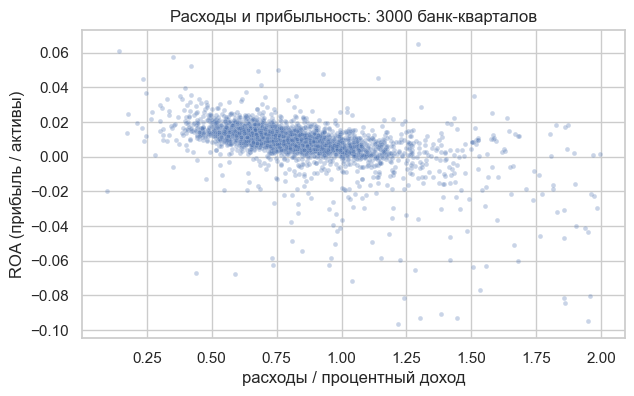

In [4]:
sns.scatterplot(
    data=show,          # таблица
    x="m_cost_income",  # что по горизонтали
    y="e_roa",          # что по вертикали
    alpha=0.3,          # прозрачность: там, где точек много, пятно темнее
    s=12)               # размер точки
plt.title("Расходы и прибыльность: 3000 банк-кварталов")
plt.xlabel("расходы / процентный доход")
plt.ylabel("ROA (прибыль / активы)")
plt.show()

Облако наклонено вниз, и через него хочется провести прямую. Вот это решение — описать связь именно **прямой** — и есть линейная регрессия.

### 2.2 Формулировка

Мы предполагаем, что связь устроена так:

$$ Y = \beta_0 + \beta_1 X + \varepsilon $$

Разберём по буквам:

* $\beta_0$ — **свободный член** (intercept, константа). Значение $Y$, когда $X = 0$. Точка, в которой прямая пересекает вертикальную ось.
* $\beta_1$ — **коэффициент наклона** (slope). На сколько меняется $Y$, если $X$ вырастет на единицу.
* $\varepsilon$ — **ошибка**: всё, что влияет на $Y$, но в модель не попало. Она не наблюдается.

$\beta_0$ и $\beta_1$ — **неизвестные числа**. Мы их не знаем и никогда не узнаем; мы их **оцениваем** по данным. Оценки принято помечать «крышкой»: $\hat\beta_0$, $\hat\beta_1$.

Имея оценки, мы для каждого банка можем посчитать **предсказание**:

$$ \hat{y}_i = \hat\beta_0 + \hat\beta_1 x_i $$

и **остаток** — насколько мы промахнулись:

$$ e_i = y_i - \hat{y}_i $$

> Не путайте: $\varepsilon$ — ненаблюдаемая ошибка модели, $e_i$ — наблюдаемый остаток, который мы посчитали. Первая — неснижаемая ошибка, второй — наша оценка.

Нарисуем это буквально: возьмём 25 банков, проведём прямую и покажем остатки вертикальными отрезками.

In [5]:
# Берём совсем маленькую выборку, чтобы отрезки не слились в кашу
tiny = banks.sample(25, random_state=SEED)

# Оцениваем прямую на этих 25 точках (подробнее про smf.ols — через две ячейки)
fit_tiny = smf.ols("e_roa ~ m_cost_income", data=tiny).fit()

# .fittedvalues — предсказания модели для тех же строк, на которых она обучалась
tiny = tiny.assign(pred=fit_tiny.fittedvalues)

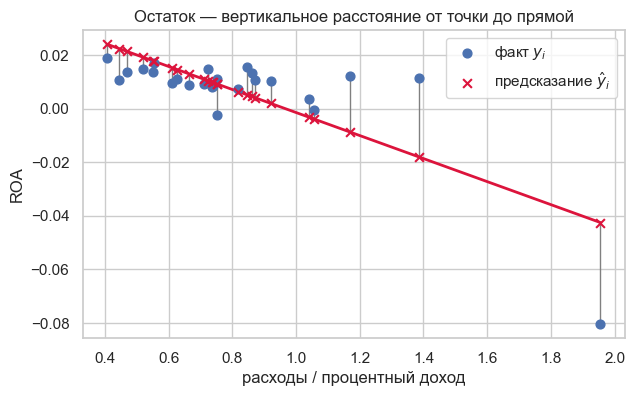

In [6]:
# Точки — факт, крестики — предсказание, серые отрезки между ними — остатки
plt.scatter(tiny["m_cost_income"], tiny["e_roa"], s=40, zorder=3, label="факт $y_i$")
plt.scatter(tiny["m_cost_income"], tiny["pred"], s=40, marker="x",
            color="crimson", zorder=3, label="предсказание $\\hat y_i$")

# Цикл по строкам таблицы: для каждой рисуем вертикальный отрезок от факта к предсказанию.
# .itertuples() выдаёт строки одну за другой; row.m_cost_income — значение колонки в строке.
for row in tiny.itertuples():
    plt.plot([row.m_cost_income, row.m_cost_income],   # x одинаковый: отрезок вертикальный
             [row.e_roa, row.pred],                    # от факта до предсказания
             color="grey", lw=1, zorder=1)

# Сама линия регрессии: две крайние точки соединяем прямой
grid_x = np.array([tiny["m_cost_income"].min(), tiny["m_cost_income"].max()])
plt.plot(grid_x, fit_tiny.params["Intercept"] + fit_tiny.params["m_cost_income"] * grid_x,
         color="crimson", lw=2, zorder=2)

plt.title("Остаток — вертикальное расстояние от точки до прямой")
plt.xlabel("расходы / процентный доход")
plt.ylabel("ROA")
plt.legend()
plt.show()

Серые отрезки — это и есть остатки. Обратите внимание: они **вертикальные**, а не перпендикулярные прямой. Регрессия минимизирует ошибку по $Y$, а не расстояние до линии; $X$ считается известным.

### 2.3 Оцениваем модель

Теперь то же самое на всех 95 тысячах строк. Формула `"e_roa ~ m_cost_income"` читается как «объясняем `e_roa` через `m_cost_income`»; свободный член добавляется сам, прописывать его нет необходимости.

In [9]:
# ols = ordinary least squares, обычный МНК.
# Слева от ~ зависимая переменная, справа — независимые.
# .fit() запускает оценивание и возвращает объект с результатами.
model_simple = smf.ols("e_roa ~ m_cost_income", data=banks).fit()

# .params — оценённые коэффициенты, обращаемся к нужному по имени
print("beta_0 (свободный член) =", round(model_simple.params["Intercept"], 5))
print("beta_1 (наклон)         =", round(model_simple.params["m_cost_income"], 5))

beta_0 (свободный член) = 0.02799
beta_1 (наклон)         = -0.02394


Прочитаем вслух. Коэффициенты выражены в долях единицы, поэтому переведём их в понятные величины: **1 базисный пункт (б.п.) = 0.01 %**, то есть 0.0001 в долях.

* $\hat\beta_0 = 0.028$: банк, у которого расходы равны нулю, имел бы ROA 2.8 %. Это экстраполяция за пределы данных — таких банков в выборке нет, и содержательного смысла у числа нет. Свободный член нужен, чтобы прямая встала на правильную высоту, а не для интерпретации. Хотя бывают и исключения (напр., если бы мы оценивали стоимость квадратного метра жилья)
* $\hat\beta_1 = -0.0239$: если расходы вырастут на **1 доллар на доллар дохода** (то есть на 1.0 по шкале `m_cost_income`), ROA упадёт на 0.0239, то есть на 239 б.п. Шаг в 1.0 огромен — в действительности банки живут в диапазоне 0.5–1.2. Считаем по реалистичному шагу.

In [8]:
b1 = model_simple.params["m_cost_income"]

# 0.10 — шаг в 10 процентных пунктов cost/income; 10 000 — перевод доли ROA в базисные пункты
print(f"+0.10 к cost/income  ->  {b1 * 0.10 * 10_000:+.0f} б.п. ROA")

# Насколько это много? Сравним с типичным уровнем ROA
print(f"для сравнения, медианный ROA = {banks['e_roa'].median() * 10_000:.0f} б.п.")

+0.10 к cost/income  ->  -24 б.п. ROA
для сравнения, медианный ROA = 91 б.п.


Рост расходов на 10 процентных пунктов стоит 24 б.п. прибыльности — примерно четверть медианного ROA. Это уже осмысленное экономическое утверждение. Можно использовать, например, при бюджетировании. 

**Важное правило: коэффициент переводим всегда в единицы, которые можно интерпретировать.** Сырое число из таблицы почти всегда либо микроскопическое, либо абсурдно большое, потому что шаг «на единицу» (чего?) бессмысленный.

## 3. RSS: что именно минимизирует МНК

### 3.1 Критерий

Прямых, которые можно провести через облако точек, бесконечно много. Какая из них «лучшая»?

Метод наименьших квадратов отвечает: та, у которой **сумма квадратов остатков** минимальна.

$$ \text{RSS}(\beta_0, \beta_1) = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} \big(y_i - \beta_0 - \beta_1 x_i\big)^2 $$

RSS — residual sum of squares. Три вопроса, которые обычно возникают:

* **Почему сумма, а не среднее?** Разницы нет: делить на $n$ — значит делить на константу, минимум там же.
* **Почему квадрат, а не модуль?** Во-первых, квадрат даёт единственное решение в явном виде (формулу, а не перебор). Во-вторых, минимизация квадрата приближает **среднее**, а модуля — медиану. Мы хотим среднее.
* **Почему остатки не сокращаются, ведь часть положительна, а часть отрицательна?** Именно поэтому и квадрат: он делает все слагаемые положительными, и промахи вверх не компенсируют промахи вниз.

Дальше — до самого §7 — мы будем часто работать на **маленькой выборке в 500 строк**. Так все эффекты видны: при 95 тысячах наблюдений почти всё вырождается — доверительные интервалы схлопываются в точку, а любая связь становится «значимой».

In [10]:
# Маленькая выборка: делаем вид, что данных у нас мало. Так честнее и нагляднее.
small = banks.sample(500, random_state=SEED)

# Оцениваем ту же модель на ней
model_small = smf.ols("e_roa ~ m_cost_income", data=small).fit()

print("на 95 610 строках: beta_1 =", round(model_simple.params["m_cost_income"], 5))
print("на 500 строках:    beta_1 =", round(model_small.params["m_cost_income"], 5))

на 95 610 строках: beta_1 = -0.02394
на 500 строках:    beta_1 = -0.02917


Оценки близки, но не совпадают: **оценка зависит от того, какая выборка нам досталась**.

### 3.2 RSS как функция наклона

Начнём с простого: зафиксируем свободный член на его оценке и переберём разные наклоны. Для каждого посчитаем RSS.

In [11]:
# Достаём колонки как массивы numpy: с ними удобнее считать
x = small["m_cost_income"].to_numpy()
y = small["e_roa"].to_numpy()

# Фиксируем свободный член на оценке МНК
b0_hat = model_small.params["Intercept"]
b1_hat = model_small.params["m_cost_income"]

# np.linspace(a, b, n) — n равномерно расположенных чисел от a до b
slopes = np.linspace(-0.06, 0.00, 200)

# Считаем RSS для каждого наклона обычным циклом
rss_by_slope = []
for b1 in slopes:
    residuals = y - (b0_hat + b1 * x)   # остатки при этом наклоне
    rss_by_slope.append(np.sum(residuals ** 2))   # сумма их квадратов

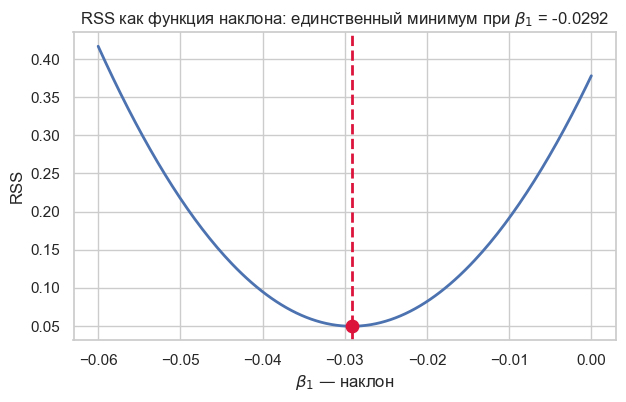

In [11]:
plt.plot(slopes, rss_by_slope, lw=2)

# Вертикальная линия в точке, которую нашёл МНК
plt.axvline(b1_hat, color="crimson", ls="--", lw=2)
plt.scatter([b1_hat], [np.sum((y - (b0_hat + b1_hat * x)) ** 2)],
            color="crimson", s=80, zorder=5)

plt.title(f"RSS как функция наклона: единственный минимум при $\\beta_1$ = {b1_hat:.4f}")
plt.xlabel("$\\beta_1$ — наклон")
plt.ylabel("RSS")
plt.show()

Парабола с одним минимумом. Никакого перебора на самом деле не нужно — минимум находится формулой, но полезно один раз написать руками и увидеть, что «метод наименьших квадратов» — это буквально поиск дна этой кривой.

### 3.3 RSS как поверхность над двумя коэффициентами

Теперь отпустим оба коэффициента. RSS становится функцией **двух** аргументов, то есть поверхностью над плоскостью $(\beta_0, \beta_1)$: слева линии уровня, справа сама поверхность, красная точка — оценка МНК.

Считаем на сетке: перебираем 60 значений $\beta_0$ на 60 значений $\beta_1$ и в каждой из 3600 точек считаем RSS.

In [12]:
# Две шкалы вокруг найденных оценок
b0_grid = np.linspace(b0_hat - 0.012, b0_hat + 0.012, 60)
b1_grid = np.linspace(b1_hat - 0.014, b1_hat + 0.014, 60)

# Пустая таблица 60x60, которую сейчас заполним значениями RSS
rss_surface = np.zeros((len(b1_grid), len(b0_grid)))

# Двойной цикл: по строкам (наклон) и по колонкам (свободный член)
for i, b1 in enumerate(b1_grid):
    for j, b0 in enumerate(b0_grid):
        residuals = y - (b0 + b1 * x)
        rss_surface[i, j] = np.sum(residuals ** 2)

# np.meshgrid делает из двух шкал решётку координат — она нужна графикам
B0, B1 = np.meshgrid(b0_grid, b1_grid)

print("минимум RSS на сетке:", round(rss_surface.min(), 6))
print("минимум RSS у МНК:   ", round(np.sum((y - (b0_hat + b1_hat * x)) ** 2), 6))

минимум RSS на сетке: 0.049576
минимум RSS у МНК:    0.049574


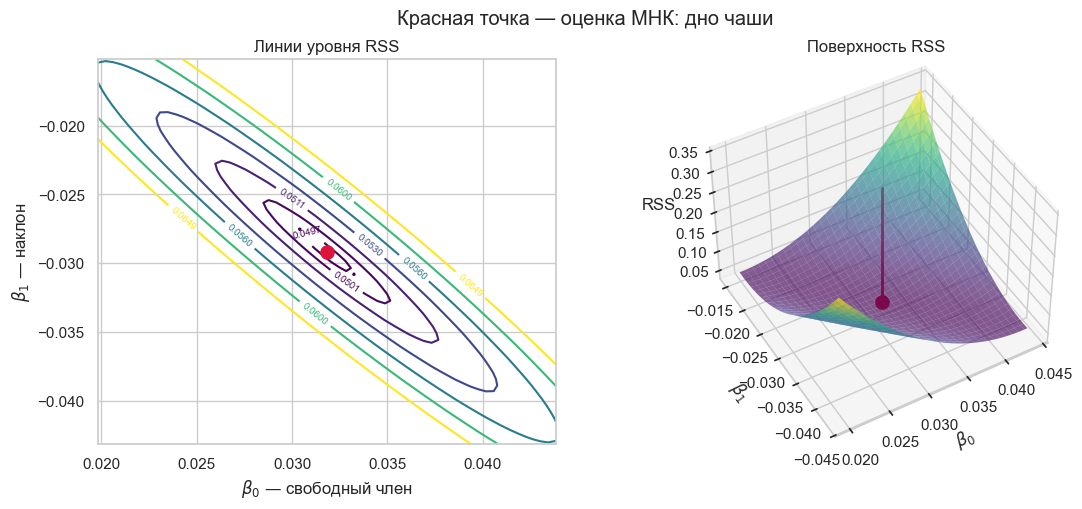

In [16]:
fig = plt.figure(figsize=(13, 5))

# --- слева: линии уровня (contour) ---
ax1 = fig.add_subplot(1, 2, 1)
# levels — на каких значениях RSS рисовать линии; берём их гуще у минимума
levels = rss_surface.min() * np.array([1.002, 1.01, 1.03, 1.07, 1.13, 1.21, 1.31])
cs = ax1.contour(B0, B1, rss_surface, levels=levels, cmap="viridis")
ax1.clabel(cs, inline=True, fontsize=7, fmt="%.4f")   # подписи на линиях
ax1.scatter([b0_hat], [b1_hat], color="crimson", s=90, zorder=5)
ax1.set_xlabel("$\\beta_0$ — свободный член")
ax1.set_ylabel("$\\beta_1$ — наклон")
ax1.set_title("Линии уровня RSS")

# --- справа: та же поверхность в 3D ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")   # projection="3d" — трёхмерные оси
ax2.plot_surface(B0, B1, rss_surface, cmap="viridis", alpha=0.65, edgecolor="none")

# Вертикальная "спица" в точке минимума: сквозь полупрозрачную поверхность её видно
ax2.plot([b0_hat, b0_hat], [b1_hat, b1_hat], [rss_surface.min(), rss_surface.max()],
         color="crimson", lw=2)
ax2.scatter([b0_hat], [b1_hat], [rss_surface.min()],
            color="crimson", s=90, depthshade=False)

ax2.set_xlabel("$\\beta_0$")
ax2.set_ylabel("$\\beta_1$")
ax2.set_zlabel("RSS")
ax2.set_title("Поверхность RSS")
ax2.view_init(elev=45, azim=-120)   # угол, с которого смотрим

fig.suptitle("Красная точка — оценка МНК: дно чаши")
plt.show()

Читаем картинку:

* Поверхность справа — **чаша** или загибающийся со всех сторон лист. У неё ровно одно дно, и красная точка сидит именно в нём. Это и есть $(\hat\beta_0, \hat\beta_1)$. Эта точка - единственная
* Линии уровня слева — **эллипсы**, вытянутые по диагонали. Диагональ означает, что $\beta_0$ и $\beta_1$ связаны: если немного увеличить наклон, можно почти компенсировать это уменьшением свободного члена, и RSS почти не изменится.
* Чем **уже** эллипсы в каком-то направлении, тем **точнее** определён коэффициент в этом направлении. Широкая пологая долина означает, что многие пары коэффициентов почти одинаково хороши, — то есть оценка ненадёжна.

Ширина чаши и есть стандартная ошибка. А в §11 мы увидим, что коллинеарность — это когда чаша вырождается в очень длинную и плоскую лощину.

## 4. Стандартные ошибки и доверительные интервалы

### 4.1 Коэффициент — это случайная величина

Вот главная мысль всей главы, и она простая.

Наши 95 610 строк — это **одна выборка** (не генеральная совокупность, кстати - а почему?). Данные могли сложиться иначе: другие банки, другие кварталы, другая случайность. Тогда и точки в облаке легли бы иначе, и прямая прошла бы чуть-чуть по-другому, и $\hat\beta_1$ получился бы другим.

Значит, $\hat\beta_1$ — это **не число, а случайная величина**. У неё есть распределение. Наша конкретная оценка — одно значение, вытянутое из этого распределения.

Проверим это буквально. Сделаем вид, что мы 300 раз проводим независимое исследование: каждый раз берём случайные 500 строк и считаем регрессию заново.

In [13]:
# Списки, куда будем складывать результаты 300 "исследований"
betas = []          # оценки наклона
se_plain = []       # стандартные ошибки по обычной формуле
se_robust = []      # стандартные ошибки по робастной формуле (понадобятся в §4.2)

# Цикл: 300 раз повторяем одно и то же исследование на новых 500 строках
for i in range(300):
    # SEED + i — каждый раз другой сид, значит другая выборка,
    # но весь эксперимент воспроизводится при перезапуске
    sample_i = banks.sample(500, random_state=SEED + i)

    fit_i = smf.ols("e_roa ~ m_cost_income", data=sample_i).fit()
    betas.append(fit_i.params["m_cost_income"])
    se_plain.append(fit_i.bse["m_cost_income"])       # .bse = beta standard errors

    # та же модель, другая формула стандартных ошибок
    fit_robust_i = smf.ols("e_roa ~ m_cost_income", data=sample_i).fit(cov_type="HC1")
    se_robust.append(fit_robust_i.bse["m_cost_income"])

# Превращаем списки в массивы numpy — с ними считать удобнее
betas = np.array(betas)
se_plain = np.array(se_plain)
se_robust = np.array(se_robust)

print("300 оценок одного и того же коэффициента:")
print("  среднее:", round(betas.mean(), 5))
print("  минимум:", round(betas.min(), 5))
print("  максимум:", round(betas.max(), 5))

300 оценок одного и того же коэффициента:
  среднее: -0.02405
  минимум: -0.03371
  максимум: -0.0161


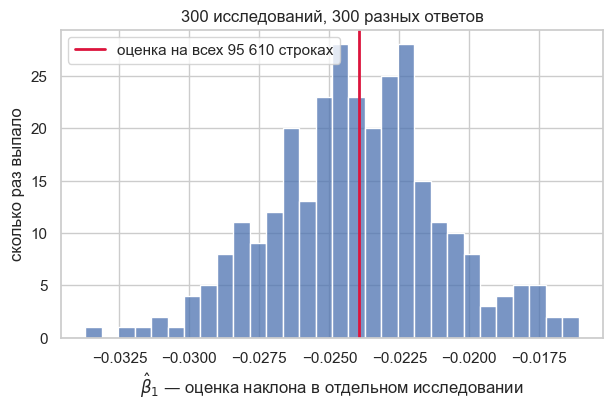

In [14]:
sns.histplot(betas, bins=30)

# Оценка на полной выборке — то, к чему всё это сходится
plt.axvline(model_simple.params["m_cost_income"], color="crimson", lw=2,
            label="оценка на всех 95 610 строках")

plt.title("300 исследований, 300 разных ответов")
plt.xlabel("$\\hat\\beta_1$ — оценка наклона в отдельном исследовании")
plt.ylabel("сколько раз выпало")
plt.legend()
plt.show()

Разброс большой: от −0.033 до −0.015, то есть от 33 до 15 б.п. на 10 п.п. расходов. Два добросовестных исследователя с одинаковой методикой и разными выборками получат заметно разные числа. Гистограмма при этом **симметрична и центрирована** там, где лежит оценка по всем данным.

### 4.2 Стандартная ошибка

**Стандартная ошибка (SE) коэффициента — это стандартное отклонение вот этой гистограммы.** Всё определение.

Она отвечает на вопрос: «насколько сильно моя оценка гуляла бы, повторись исследование?»

Но в реальной жизни выборка одна, и 300 раз повторить эксперимент нельзя. Поэтому SE считают **формулой** по единственной имеющейся выборке. `statsmodels` печатает её в колонке `std err`. Сравним формулу с экспериментом.

Формула, посчитанная по одной выборке, — это тоже оценка, и у неё тоже есть разброс. Поэтому сравнивать честно так: разброс оценок из эксперимента против **среднего** того, что формула выдавала в тех же 300 повторах.

In [23]:
# Разброс, который мы намерили экспериментом (ddof=1 — несмещённая оценка sd)
se_experiment = betas.std(ddof=1)

print(f"разброс оценок в эксперименте:  {se_experiment:.5f}")
print(f"обычная формула, в среднем:     {se_plain.mean():.5f}")
print(f"формула занижает разброс в {se_experiment / se_plain.mean():.1f} раза")

разброс оценок в эксперименте:  0.00308
обычная формула, в среднем:     0.00181
формула занижает разброс в 1.7 раза


Формула **занижает** разброс почти вдвое. Это не опечатка и не ошибка `statsmodels`.

Дело в том, что обычная формула SE опирается на предположение: **все точки зашумлены одинаково сильно**. Оно называется гомоскедастичностью, и в наших данных оно неверно — в §10 мы увидим это на картинке. Если предположение снять, SE считается по-другому. Такие стандартные ошибки называют **робастными**; в `statsmodels` они включаются одним аргументом `cov_type="HC1"` — мы уже посчитали их в цикле выше.

In [17]:
print(f"разброс оценок в эксперименте:  {se_experiment:.5f}")
print(f"обычная формула, в среднем:     {se_plain.mean():.5f}")
print(f"робастная формула, в среднем:   {se_robust.mean():.5f}   <- вот теперь совпало")

разброс оценок в эксперименте:  0.00302
обычная формула, в среднем:     0.00182
робастная формула, в среднем:   0.00312   <- вот теперь совпало


In [18]:
# Проверим заодно, что робастная поправка НЕ трогает сам коэффициент
model_small_robust = smf.ols("e_roa ~ m_cost_income", data=small).fit(cov_type="HC1")

print("коэффициент обычный:  ", round(model_small.params["m_cost_income"], 5))
print("коэффициент робастный:", round(model_small_robust.params["m_cost_income"], 5))
print()
print("SE обычная:  ", round(model_small.bse["m_cost_income"], 5))
print("SE робастная:", round(model_small_robust.bse["m_cost_income"], 5))

коэффициент обычный:   -0.02917
коэффициент робастный: -0.02917

SE обычная:   0.00173
SE робастная: 0.00368


Робастная формула попала в эксперимент почти точно: 0.0031 против измеренных 0.0030.

И заметьте: **сам коэффициент не изменился ни на знак**. Поправки на стандартные ошибки не трогают оценку, они трогают только нашу уверенность в ней. Обратите внимание и на второе: на **одной** конкретной выборке робастная SE дала 0.0037 — то есть сама она тоже гуляет от выборки к выборке. Правильна она в среднем, а не в каждом отдельном случае.

### 4.3 Доверительный интервал

SE — это разброс. Доверительный интервал — то же самое, но в удобной для интерпретации форме:

$$ \hat\beta_1 \pm t_{крит} \cdot \text{SE}(\hat\beta_1) $$

При большой выборке $t_{крит} \approx 1.96$, и почти всегда говорят просто «плюс-минус два стандартных отклонения». `statsmodels` печатает интервал в колонках `[0.025  0.975]`.

**Что означает «95 %».** Не «истинный $\beta_1$ лежит здесь с вероятностью 95 %» — истинный $\beta_1$ это фиксированное число, оно либо внутри, либо нет. Правильно так: **если повторить исследование много раз, 95 % построенных интервалов перекроют истинное значение**.

Это утверждение можно проверить в коде. Так мы сразу увидим, чем плохи заниженные SE.

In [ ]:
# Считаем "истиной" оценку по всем 95 610 строкам: она наша лучшая догадка о beta_1
beta_true = model_simple.params["m_cost_income"]

# Счётчики попаданий для двух версий интервала
hits_plain = 0
hits_robust = 0

for i in range(300):
    sample_i = banks.sample(500, random_state=SEED + i)

    # обычный интервал
    fit_plain = smf.ols("e_roa ~ m_cost_income", data=sample_i).fit()
    lo, hi = fit_plain.conf_int().loc["m_cost_income"]   # .conf_int() — границы интервала
    if lo <= beta_true <= hi:
        hits_plain += 1

    # робастный интервал
    fit_robust = smf.ols("e_roa ~ m_cost_income", data=sample_i).fit(cov_type="HC1")
    lo, hi = fit_robust.conf_int().loc["m_cost_income"]
    if lo <= beta_true <= hi:
        hits_robust += 1

print(f"обычный 95% интервал накрыл истинное значение в  {hits_plain} случаях из 300 = {hits_plain / 300:.0%}")
print(f"робастный 95% интервал накрыл истинное значение в {hits_robust} случаях из 300 = {hits_robust / 300:.0%}")

обычный 95% интервал накрыл истину в  225 случаях из 300 = 75%
робастный 95% интервал накрыл истину в 283 случаях из 300 = 94%


Робастный интервал работает как часы: 94 % вместо 95 %, отличие в пределах случайности эксперимента. Обычный накрывает истину лишь в 75 % случаев — то есть **каждый четвёртый раз он существенно занижает оценки**, хотя на нём написано «95 %».

Вот чем опасны заниженные стандартные ошибки: не тем, что коэффициент неверен, а тем, что мы **уверены в нём сильнее, чем имеем право**. К механизму вернёмся в §10.

Посмотрим, как выглядит интервал на картинке — и заодно как он сужается с ростом выборки.

In [15]:
# Оцениваем одну и ту же модель на выборках разного размера
sizes = [50, 100, 500, 2000, 10_000, len(banks)]

rows = []
for n in sizes:
    # если n равен всей выборке — берём её целиком, иначе случайные n строк
    sample_n = banks if n == len(banks) else banks.sample(n, random_state=SEED)
    fit_n = smf.ols("e_roa ~ m_cost_income", data=sample_n).fit(cov_type="HC1")
    lo, hi = fit_n.conf_int().loc["m_cost_income"]
    rows.append({"n": n,
                 "beta_1": fit_n.params["m_cost_income"],
                 "нижняя": lo, "верхняя": hi,
                 "ширина ДИ": hi - lo})

ci_table = pd.DataFrame(rows)
ci_table.round(5)

,n,beta_1,нижняя,верхняя,ширина ДИ
0,50,-0.04281,-0.06970,-0.01593,0.05377
1,100,-0.03866,-0.05788,-0.01944,0.03844
2,500,-0.02917,-0.03638,-0.02195,0.01442
3,2000,-0.02623,-0.02984,-0.02263,0.00721
4,10000,-0.02490,-0.02634,-0.02347,0.00287
5,95610,-0.02394,-0.02440,-0.02349,0.00090


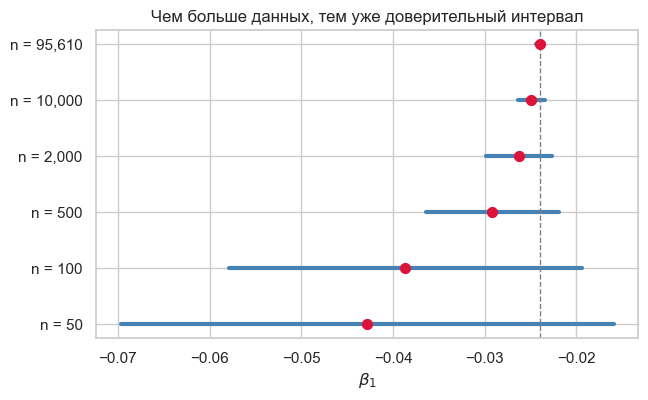

In [21]:
# Рисуем интервалы горизонтальными отрезками, один под другим
for k, row in enumerate(ci_table.itertuples()):
    plt.plot([row.нижняя, row.верхняя], [k, k], lw=3, color="steelblue")
    plt.scatter([row.beta_1], [k], color="crimson", s=50, zorder=5)

plt.yticks(range(len(ci_table)), [f"n = {n:,}" for n in ci_table["n"]])
plt.axvline(beta_true, color="grey", ls="--", lw=1)
plt.title("Чем больше данных, тем уже доверительный интервал")
plt.xlabel("$\\beta_1$")
plt.show()

Интервал сжимается как $1/\sqrt{n}$: чтобы сделать его вдвое уже, данных нужно вчетверо больше. При $n = 50$ он настолько широк, что даже знак эффекта под вопросом; при $n = 95\,610$ он схлопнулся почти в точку.

Отсюда важное следствие, к которому мы вернёмся в далее: **на большой выборке «значимо» становится почти всё**, и значимость перестаёт нести информацию. Начинается отбор коэффициентов. 

## 5. Читаем стандартную таблицу: гипотезы, $t$, $F$, $R^2$

### 5.1 Нулевая и альтернативная гипотезы

Регрессия оценила $\hat\beta_1 = -0.029$. Но мы только что выяснили, что оценка гуляет от выборки к выборке. Может ли быть, что на самом деле связи нет вообще, а мы просто вытянули неудачную выборку?

Формально это оформляется как проверка гипотезы:

* $H_0: \beta_1 = 0$ — **нулевая гипотеза**: связи нет, $X$ не помогает объяснять $Y$;
* $H_1: \beta_1 \neq 0$ — **альтернативная**: связь есть, знак любой.

Логика проверки такая. Предположим, что $H_0$ верна. Насколько неправдоподобно тогда выглядит то, что мы увидели? Если очень — $H_0$ отвергаем.

### 5.2 $t$-статистика

Мера «неправдоподобности» — это просто оценка, поделённая на её стандартную ошибку:

$$ t = \frac{\hat\beta_1 - 0}{\text{SE}(\hat\beta_1)} $$

Читается буквально: **на сколько стандартных ошибок оценка отстоит от нуля**. Если $|t|$ больше примерно 2, оценка отстоит от нуля дальше, чем обычный размах случайных колебаний, — такое трудно объяснить чистой случайностью.

In [26]:
# Считаем t руками и сверяем с тем, что печатает statsmodels
b = model_small.params["m_cost_income"]
se = model_small.bse["m_cost_income"]

print("beta_1 =", round(b, 5))
print("SE     =", round(se, 5))
print("t      =", round(b / se, 2), "  <- посчитали сами")
print("t      =", round(model_small.tvalues["m_cost_income"], 2), "  <- .tvalues")

beta_1 = -0.02917
SE     = 0.00173
t      = -16.9   <- посчитали сами
t      = -16.9   <- .tvalues


### 5.3 $p$-значение

$t = -16.9$ — оценка отстоит от нуля на семнадцать стандартных ошибок. Насколько это редкое событие, если $H_0$ верна?

**$p$-значение — это вероятность увидеть $|t|$ не меньше наблюдённого, если нулевая гипотеза верна.** Маленькое $p$ означает: данные плохо согласуются с «связи нет».

Порог 0.05 — соглашение, а не закон природы. Никакого физического смысла у него нет.

In [23]:
print("p-значение:", model_small.pvalues["m_cost_income"])

# То же в читаемом виде: statsmodels печатает 0.000, когда p меньше 0.0005
print("p < 0.001?", model_small.pvalues["m_cost_income"] < 0.001)

p-значение: 5.55851020071288e-51
p < 0.001? True


> **Чего $p$-значение НЕ означает.** Это не вероятность того, что $H_0$ верна. Это не вероятность того, что вы ошиблись. И это точно не мера **величины** эффекта: $p = 10^{-50}$ не значит, что эффект большой, — значит, что он имеет свойство воспроизводиться.

### 5.4 $F$-статистика

$t$ проверяет один коэффициент. $F$ проверяет **все наклоны сразу**:

* $H_0: \beta_1 = \beta_2 = \dots = \beta_p = 0$ — ни один признак не помогает;
* $H_1$: хотя бы один коэффициент не равен нулю.

Зачем отдельный тест, если есть $t$? Потому что при десяти бесполезных признаках и пороге 0.05 хотя бы один «значимый» результат появится случайно примерно в 40 % случаев ($1 - 0.95^{10}$) — просто от количества попыток. $F$ смотрит на модель целиком и от этой проблемы свободен.

В парной регрессии всё вырождается: признак один, и $F = t^2$. Проверим.

In [24]:
print("F-статистика:", round(model_small.fvalue, 1))
print("t в квадрате:", round(model_small.tvalues["m_cost_income"] ** 2, 1))
print("p для F:     ", model_small.f_pvalue)

F-статистика: 285.6
t в квадрате: 285.6
p для F:      5.558510200712556e-51


### 5.5 $R^2$

$R^2$ отвечает на другой вопрос — не «есть ли связь», а «**какую долю разброса $Y$ модель объяснила**».

Считается он из трёх сумм квадратов:

* $\text{TSS} = \sum (y_i - \bar y)^2$ — общий разброс $Y$ вокруг среднего. Это ошибка **самой глупой модели**: «всегда предсказываю среднее».
* $\text{RSS} = \sum (y_i - \hat y_i)^2$ — то, что осталось после регрессии.

$$ R^2 = \frac{\text{TSS} - \text{RSS}}{\text{TSS}} = 1 - \frac{\text{RSS}}{\text{TSS}} $$

То есть $R^2$ — это **доля ошибки, которую модель убрала** по сравнению с предсказанием среднего. $R^2 = 0$ — модель не лучше среднего; $R^2 = 1$ — идеальное попадание во все точки.

Посчитаем руками.

In [25]:
y_small = small["e_roa"].to_numpy()

tss = np.sum((y_small - y_small.mean()) ** 2)          # разброс вокруг среднего
rss = np.sum(model_small.resid.to_numpy() ** 2)        # .resid — остатки модели

print("TSS =", round(tss, 5))
print("RSS =", round(rss, 5))
print("R^2 =", round(1 - rss / tss, 4), "  <- посчитали сами")
print("R^2 =", round(model_small.rsquared, 4), "  <- .rsquared")

TSS = 0.07801
RSS = 0.04957
R^2 = 0.3645   <- посчитали сами
R^2 = 0.3645   <- .rsquared


### 5.6 Вся таблица целиком

Теперь напечатаем полный `summary()` и пройдём по нему построчно. Это тот объект, который показывает основные результаты, и каждое число в нём надо уметь прочитать.

In [16]:
print(model_small.summary())

                            OLS Regression Results                            
Dep. Variable:                  e_roa   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     285.6
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           5.56e-51
Time:                        23:39:54   Log-Likelihood:                 1595.3
No. Observations:                 500   AIC:                            -3187.
Df Residuals:                     498   BIC:                            -3178.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0318      0.002     20.988

**Шапка — про выборку и про модель в целом.**

| Строка | Что это |
|---|---|
| `Dep. Variable` | что объясняем |
| `No. Observations` | сколько строк реально участвовало. Сравните с размером таблицы: строки с пропусками выбрасываются молча |
| `Df Residuals` | степени свободы остатков, $n - p - 1$ (см. §6) |
| `Df Model` | сколько наклонов в модели ($p$) |
| `R-squared` | доля объяснённого разброса, §5.5 |
| `Adj. R-squared` | то же со штрафом за число признаков, §6.3 |
| `F-statistic` / `Prob (F-statistic)` | тест «все наклоны равны нулю разом», §5.4 |
| `Covariance Type` | **по какой формуле посчитаны все SE справа**. `nonrobust` — обычная; если данные панельные или разброс неоднороден, читать таблицу дальше рано (§4.2, §10) |

**Тело — про отдельные коэффициенты.**

| Колонка | Что это |
|---|---|
| `coef` | оценка $\hat\beta_j$, в единицах данных |
| `std err` | стандартная ошибка, §4.2 |
| `t` | $\hat\beta_j / \text{SE}$, §5.2 |
| `P>|t|` | $p$-значение, §5.3 |
| `[0.025  0.975]` | 95 % доверительный интервал, §4.3 |

### 5.7 Значимость — не то же самое, что важность

Сравним ту же самую модель на 500 строках и на всех 95 610.

In [27]:
# Собираем ключевые числа обеих моделей в одну табличку для сравнения
compare = pd.DataFrame({
    "n = 500":    [model_small.params["m_cost_income"],
                   model_small.bse["m_cost_income"],
                   model_small.tvalues["m_cost_income"],
                   model_small.rsquared],
    "n = 95 610": [model_simple.params["m_cost_income"],
                   model_simple.bse["m_cost_income"],
                   model_simple.tvalues["m_cost_income"],
                   model_simple.rsquared],
}, index=["коэффициент", "стандартная ошибка", "t-статистика", "R^2"])

compare.round(5)

,n = 500,n = 95 610
коэффициент,-0.02917,-0.02394
стандартная ошибка,0.00173,0.00013
t-статистика,-16.90107,-182.32556
R^2,0.36451,0.25799


Коэффициент изменился мало: −0.029 против −0.024, обе выборки говорят примерно об одном и том же эффекте. А вот $t$ вырос с 17 до 182 — ровно потому, что SE упала в 14 раз ($\sqrt{95610/500} \approx 13.8$).

($R^2$ по дороге тоже разошёлся: 0.36 на пятистах строках против 0.26 на всех. Он ведь тоже оценка по выборке и тоже гуляет — на 500 строках нам просто досталось облако поплотнее.)

Отсюда два практических вывода:

1. **$t$ и $p$ измеряют не силу эффекта, а точность его измерения.** При $n = 95\,610$ значимым окажется почти всё, включая эффекты, которые не имеют никакого практического смысла.
2. **Судить о важности надо по величине коэффициента в понятных единицах** и по ширине доверительного интервала — как мы делали в §2.3.

Хорошая формулировка результата звучит так: *«рост cost/income на 10 п.п. сопровождается падением ROA на 24 б.п., доверительный интервал — от 23.5 до 24.4 б.п.»* Это утверждение можно проверить и оспорить. С «$p < 0.001$» ничего содержательного сделать нельзя.

## 6. $R^2$, корреляция и степени свободы

### 6.1 В парной регрессии $R^2$ — это просто квадрат корреляции

Корреляция $r$ и $R^2$ — разные вещи, но в **парной** регрессии связаны точным равенством:

$$ R^2 = r^2 $$

Проверим кодом.

In [28]:
# .corr() между двумя колонками — обычный коэффициент корреляции Пирсона
r = small["e_roa"].corr(small["m_cost_income"])

print("корреляция r      =", round(r, 4))
print("r в квадрате      =", round(r ** 2, 4))
print("R^2 регрессии     =", round(model_small.rsquared, 4))

корреляция r      = -0.6037
r в квадрате      = 0.3645
R^2 регрессии     = 0.3645


Различия между ними всё же есть:

| | Корреляция $r$ | $R^2$ |
|---|---|---|
| диапазон | от −1 до +1 | от 0 до 1 |
| знак | есть: видно направление связи | нет: $R^2$ не различает рост и падение |
| сколько переменных | ровно две | сколько угодно |
| симметрия | $r(X, Y) = r(Y, X)$ | нет: $Y$ объясняем, $X$ объясняет |

**Главное отличие — третья строка.** Корреляция определена для пары переменных. Когда признаков несколько, «корреляции с $Y$» уже недостаточно: два признака могут по отдельности слабо коррелировать с $Y$, а вместе объяснять его хорошо. И наоборот, два сильно коррелированных с $Y$ признака могут дублировать друг друга и не добавить ничего (это §11).

В **множественной** регрессии равенство обобщается так: $R^2$ — это квадрат корреляции между фактом $y$ и предсказанием $\hat y$. Проверим и это, забежав вперёд в §7.

In [28]:
# Модель с четырьмя признаками — подробно разберём её в §7
model_multi_preview = smf.ols(
    "e_roa ~ m_cost_income + a_npl_gross_loans + c_equity_assets + e_nim",
    data=banks).fit()

# Корреляция факта с предсказанием
r_yhat = banks["e_roa"].corr(model_multi_preview.fittedvalues)

print("корреляция факта и предсказания:", round(r_yhat, 4))
print("её квадрат:                     ", round(r_yhat ** 2, 4))
print("R^2 модели:                     ", round(model_multi_preview.rsquared, 4))

корреляция факта и предсказания: 0.6008
её квадрат:                      0.361
R^2 модели:                      0.361


### 6.2 $R^2$ всегда растёт, когда добавляешь признак

Теперь неприятное свойство $R^2$, из-за которого его нельзя использовать для выбора модели.

**Добавление любого признака никогда не уменьшает $R^2$.** Даже если признак — чистый шум. Причина механическая: МНК минимизирует RSS по большему числу параметров, а значит найдёт RSS не хуже прежнего (в худшем случае поставит новому коэффициенту ноль).

Устроим эксперимент: возьмём 100 строк и будем добавлять в модель колонки со **случайными числами**, не имеющими к банкам никакого отношения.

In [17]:
# Генератор случайных чисел с фиксированным сидом
rng = np.random.default_rng(SEED)

# Маленькая выборка: на 100 строках эффект видно сразу
tiny100 = banks.sample(100, random_state=SEED).copy()

# Заранее создаём 95 колонок чистого шума
noise_names = []
for j in range(95):
    name = f"noise{j}"
    tiny100[name] = rng.normal(size=len(tiny100))   # случайные числа из нормального распределения
    noise_names.append(name)

print("в таблице теперь колонок:", tiny100.shape[1])

в таблице теперь колонок: 137


In [18]:
tiny100

,cert,repdte,assets,deposits,equity,loans_gross,llr,npl,securities,brokered_deposits,tier1_capital,cash,cre_loans,net_income,nii,...,noise80,noise81,noise82,noise83,noise84,noise85,noise86,noise87,noise88,noise89,noise90,noise91,noise92,noise93,noise94
130475,35095,2015-09-30,6173890.0,4802978.0,807152.0,4466369.0,37351.0,16423.0,616354.0,277117.0,650908.0,285625.0,2343942.0,17566.0,45760.0,...,-0.816538,-0.821823,0.160396,-2.071977,-0.734904,0.713446,-0.952313,-0.914470,0.752094,0.050399,0.335576,-0.007959,0.140533,1.350209,0.903992
44804,11113,2018-03-31,422459.0,325134.0,87760.0,230330.0,3433.0,3809.0,158524.0,0.0,89894.0,29641.0,17714.0,1445.0,4013.0,...,-0.381996,-0.229695,-0.915786,1.104490,-0.834854,1.167631,-0.859920,-1.280855,0.884807,1.787641,0.778095,-0.811948,0.720323,0.339835,-0.088321
99351,27078,2011-12-31,435944.0,360396.0,56177.0,333758.0,4036.0,1465.0,37390.0,28843.0,38232.0,21452.0,131707.0,1156.0,4710.0,...,-1.639445,-1.255326,2.244157,-0.886141,1.822165,-0.815442,-0.968996,1.140581,-0.202320,-0.615302,0.114229,-1.155843,-0.400027,0.935162,-0.139558
62914,15521,2006-09-30,53082.0,40731.0,8047.0,42454.0,324.0,0.0,1692.0,594.0,4262.0,1255.0,8073.0,112.0,460.0,...,-0.476797,-2.401088,-0.300470,1.450703,-0.036014,-1.448868,0.153896,-0.058249,0.226244,0.299760,-2.095366,-0.403516,-0.008940,-1.243526,1.194521
101783,27619,2002-09-30,835358.0,661421.0,160633.0,510055.0,2002.0,668.0,150905.0,0.0,153468.0,39927.0,1291.0,2241.0,6143.0,...,-0.638510,0.810032,-0.026424,0.922280,0.377145,1.223597,-1.185032,-1.243891,0.602719,0.268745,-0.711462,-0.504265,0.161860,-0.113738,1.924152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5821,1468,2011-12-31,143187.0,124797.0,15298.0,39293.0,967.0,1188.0,73141.0,0.0,13167.0,7195.0,18275.0,380.0,1018.0,...,-0.732580,-0.556766,-0.192218,-1.619135,-0.021299,0.416940,-0.698943,-0.097330,-0.294047,0.825877,1.733468,-0.610866,0.985693,0.315328,-0.696695
24548,5575,2005-06-30,127552.0,117434.0,9052.0,90076.0,916.0,225.0,23607.0,5173.0,9233.0,4495.0,50704.0,200.0,1127.0,...,-0.185799,0.071941,-0.705416,-1.436395,0.133112,0.766834,1.448196,-1.077546,0.119005,1.210023,-0.290572,-0.661245,-1.448659,0.034558,-0.574864
146567,58239,2017-06-30,299185.0,244268.0,29647.0,240671.0,3000.0,444.0,4494.0,61708.0,29653.0,44679.0,136370.0,848.0,2649.0,...,-0.562389,0.157405,-0.735417,-0.659951,1.354525,-0.898086,-1.057059,0.407762,0.150010,1.454317,-0.390077,1.501147,1.722412,0.364792,0.730611
40038,10169,2012-09-30,76951.0,68689.0,8036.0,41599.0,449.0,1250.0,16679.0,0.0,7599.0,8362.0,23446.0,262.0,928.0,...,0.303753,0.361561,0.115854,-0.969461,0.872946,0.875417,-0.042160,0.569642,0.418385,0.506554,0.378265,-2.004979,0.533948,0.307185,0.049565


In [19]:
rows = []
# Пробуем модели, где к настоящему признаку добавлено k шумовых
for k in [0, 5, 10, 20, 40, 60, 80, 95]:
    # Собираем формулу строкой: "e_roa ~ m_cost_income + noise0 + noise1 + ..."
    formula = "e_roa ~ m_cost_income"
    for name in noise_names[:k]:
        formula = formula + " + " + name

    fit_k = smf.ols(formula, data=tiny100).fit()
    rows.append({"шумовых признаков": k,
                 "R^2": fit_k.rsquared,
                 "скорректированный R^2": fit_k.rsquared_adj,
                 "степеней свободы осталось": int(fit_k.df_resid)})

pd.DataFrame(rows).set_index("шумовых признаков").round(3)

,R^2,скорректированный R^2,степеней свободы осталось
шумовых признаков,,,
0,0.512,0.508,98
5,0.554,0.525,93
10,0.575,0.522,88
20,0.602,0.495,78
40,0.727,0.534,58
60,0.815,0.519,38
80,0.920,0.561,18
95,0.998,0.933,3


$R^2$ растёт монотонно: 0.51 → 0.92 → 0.998. Модель «объяснила» 99.8 % разброса ROA случайными числами. Никакой информации в них нет — есть только свобода подгонки.

Сравните со средней колонкой: скорректированный $R^2$ всё это время болтается около 0.5 и никуда не идёт. Это и есть его работа.

### 6.3 Степени свободы

Третья колонка таблицы объясняет, что происходит. **Степени свободы остатков** — это

$$ \text{df} = n - p - 1 $$

где $n$ — число наблюдений, $p$ — число наклонов, а единица — за свободный член.

Смысл такой: у нас $n$ независимых чисел, и каждый оценённый параметр «съедает» одно из них. То, что осталось, — это количество информации, доступной для оценки разброса ошибки. Когда $n = 100$, а параметров 96, остаётся 4 степени свободы: почти вся выборка ушла на подгонку, оценивать точность практически не на чем. При $p + 1 = n$ модель прошла бы ровно через все точки, $R^2 = 1$, и она бы не значила ничего.

Представьте себе настольную лампу с множеством "коленец". Комбинации их вращения и есть степени свободы. 

Степени свободы стоят за многими числами таблицы:

* они делают $\hat\sigma^2 = \text{RSS} / (n - p - 1)$ несмещённой оценкой дисперсии ошибки, а через неё входят в **каждую стандартную ошибку**;
* они задают распределение, по которому считается $p$-значение (`Df Residuals` в шапке);
* они входят в $F$-статистику (`Df Model` и `Df Residuals`).

**Скорректированный $R^2$** — самая простая поправка на это:

$$ R^2_{adj} = 1 - \frac{\text{RSS} / (n - p - 1)}{\text{TSS} / (n - 1)} $$

Вместо сумм квадратов делятся **средние** квадраты, каждый на свои степени свободы. Добавили бесполезный признак — RSS почти не упала, а делитель $n - p - 1$ уменьшился, значит дробь выросла и $R^2_{adj}$ не вырос. Именно это видно в таблице выше: при 80 шумовых признаках $R^2 = 0.92$, а $R^2_{adj} = 0.56$, то есть ровно там же, где был в начале.

Последняя строка таблицы — забавное следствие для $R^2_{adj}$ от переизбытка степеней. При 95 шумовых признаках на 100 наблюдений остаётся **3 степени свободы**, и он показывает 0.93. Это не значит, что модель хороша; это значит, что на трёх степенях свободы он перестаёт что-либо измерять. Поправка на сложность помогает, пока данных заметно больше, чем параметров.

> $R^2_{adj}$ — костыль, а не решение. Он не отвечает на вопрос, будет ли модель работать на новых данных. На этот вопрос отвечает только проверка на отложенной выборке — то, что мы делали в §4 первой лекции.

## 7. Множественная линейная регрессия

### 7.1 Формулировка

Один признак — это почти всегда мало. Прибыльность банка зависит не только от расходов: ещё от качества кредитов, от запаса капитала, от процентной маржи. Модель расширяется:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \varepsilon $$

Ничего концептуально нового: RSS считается так же, минимизируется так же, только теперь чаша из §3 живёт не в трёхмерном, а в $(p+1)$-мерном пространстве. Нарисовать её нельзя, а посчитать — можно.

В формуле `statsmodels` признаки перечисляются через `+`.

In [21]:
# Четыре признака из разных блоков CAMELS
model_multi = smf.ols(
    "e_roa ~ m_cost_income + a_npl_gross_loans + c_equity_assets + e_nim",
    data=banks).fit()

print(model_multi.summary().tables[1])
print("R^2 =", round(model_multi.rsquared, 4))
print("R^2 парной модели (только расходы) =", round(model_simple.rsquared, 4))

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0168      0.000     90.305      0.000       0.016       0.017
m_cost_income        -0.0183      0.000   -140.220      0.000      -0.019      -0.018
a_npl_gross_loans    -0.1157      0.001    -97.015      0.000      -0.118      -0.113
c_equity_assets       0.0204      0.001     20.672      0.000       0.018       0.022
e_nim                 0.1720      0.002     70.876      0.000       0.167       0.177
R^2 = 0.361
R^2 парной модели (только расходы) = 0.258


Четыре признака вместо одного подняли $R^2$ с 0.258 до 0.361.

### 7.2 Что означает «при прочих равных»

Ключевое отличие множественной регрессии от парной — в интерпретации коэффициента.

$\beta_1$ в множественной регрессии — это изменение $Y$ при росте $X_1$ на единицу, **если остальные признаки не менялись**. Это не то же самое, что наклон в парной регрессии, где остальные признаки свободно менялись вместе с $X_1$.

Разница видна в числах.

In [22]:
# Считаем парные регрессии для каждого признака отдельно и сравниваем с множественной
features = ["m_cost_income", "a_npl_gross_loans", "c_equity_assets", "e_nim"]

rows = []
for f in features:
    pair = smf.ols(f"e_roa ~ {f}", data=banks).fit()      # парная: только этот признак
    rows.append({"признак": f,
                 "парная регрессия": pair.params[f],
                 "множественная": model_multi.params[f]})

pd.DataFrame(rows).set_index("признак").round(4)

,парная регрессия,множественная
признак,,
m_cost_income,-0.0239,-0.0183
a_npl_gross_loans,-0.1712,-0.1157
c_equity_assets,0.0570,0.0204
e_nim,0.2650,0.1720


Для расходов парный наклон −0.0239, множественный −0.0183: почти четверть «эффекта расходов» на самом деле принадлежала другим показателям, которые с расходами коррелируют (плохой банк обычно плох сразу по нескольким статьям). Множественная регрессия эту часть у расходов **отобрала и отдала** просрочке и марже.

Для капитала разница ещё заметнее: 0.057 против 0.020.

**Это и есть «контроль»**: перераспределение общей вариации между коррелированными признаками. Из этого следует:

* если признаки сильно коррелированы, делить между ними эффект становится трудно;
* если важный признак в модель не попал, его влияние «приклеится» к тем, кто в модели есть. Это пропущенная переменная, и никакая статистика её не обнаружит.

### 7.3 Сравниваем вклады в понятных единицах

Коэффициенты в сыром виде несравнимы: у показателей разный масштаб и разный реалистичный шаг. Переведём каждый в базисные пункты ROA на реалистичное изменение признака — **одно стандартное отклонение**. Это назвается стандартизацией

In [34]:
rows = []
for f in features:
    sd = banks[f].std()                                  # стандартное отклонение признака
    coef = model_multi.params[f]
    ci_lo, ci_hi = model_multi.conf_int().loc[f]          # границы доверительного интервала
    rows.append({
        "признак": f,
        "sd признака": sd,
        "коэффициент": coef,
        "эффект +1 sd, б.п.": coef * sd * 10_000,        # переводим в базисные пункты
        "нижняя граница": ci_lo * sd * 10_000,
        "верхняя граница": ci_hi * sd * 10_000,
    })

effects = pd.DataFrame(rows).set_index("признак")
effects.round(3).sort_values("эффект +1 sd, б.п.")

,sd признака,коэффициент,"эффект +1 sd, б.п.",нижняя граница,верхняя граница
признак,,,,,
m_cost_income,0.256,-0.018,-46.764,-47.417,-46.110
a_npl_gross_loans,0.027,-0.116,-31.605,-32.244,-30.967
c_equity_assets,0.032,0.020,6.544,5.924,7.165
e_nim,0.013,0.172,22.685,22.057,23.312


Теперь таблицу можно произнести вслух: *«банк-квартал, где расходы на одно стандартное отклонение выше, показывает ROA примерно на 47 б.п. ниже; доверительный интервал — от 46 до 48 б.п.»*

Ранжирование по силе: расходы (−47 б.п.) ≈ просрочка (−32) > маржа (+23) > капитал (+7). Капитал даёт самый маленький вклад, хотя его $t$-статистика равна 21 и «значимость запредельная». То есть значимость и важность — разные вопросы.

> Стандартизация — удобный, но не единственный способ сравнения. У неё есть недостаток: sd признака зависит от того, какую выборку вы взяли. Если фильтр изменится, изменятся и «стандартизованные эффекты», хотя сами коэффициенты останутся прежними.

## 8. Категориальные переменные

До сих пор все признаки были числами. Но много полезной информации — **категории**: штат, тип лицензии, отрасль, «был кризис или нет». Регрессия умеет и с ними, надо только правильно закодировать.

### 8.1 Два значения: фиктивная переменная

Начнём с самого простого случая. Сделаем признак «крупный банк»: активы выше медианы или нет.

In [23]:
# Сравнение с медианой даёт колонку из True/False
banks["big"] = banks["assets"] > banks["assets"].median()

# .value_counts() считает, сколько раз встретилось каждое значение
print(banks["big"].value_counts())

# Средний ROA в каждой группе
print()
print(banks.groupby("big")["e_roa"].mean().round(5))

big
False    47805
True     47805
Name: count, dtype: int64

big
False    0.00739
True     0.00858
Name: e_roa, dtype: float32


Такая переменная называется **фиктивной** (dummy) или индикаторной. Она принимает значение 1 (`True`) или 0 (`False`), и в модель входит как обычный признак:

$$ Y = \beta_0 + \beta_1 \cdot \text{big} + \varepsilon $$

Подставим оба значения:

* маленький банк (`big` = 0): $\hat y = \beta_0$;
* крупный банк (`big` = 1): $\hat y = \beta_0 + \beta_1$.

Значит, $\beta_0$ — это **среднее в базовой группе**, а $\beta_1$ — **разница средних между группами**. Проверим.

In [39]:
model_big = smf.ols("e_roa ~ big", data=banks).fit()
print(model_big.summary().tables[1])

# Сверяем с групповыми средними, посчитанными вручную
means = banks.groupby("big")["e_roa"].mean()
print()
print("среднее у маленьких:      ", round(means[False], 5), " = свободный член")
print("разница средних:          ", round(means[True] - means[False], 5), " = коэффициент big")

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.0074   5.51e-05    133.999      0.000       0.007       0.007
big[T.True]     0.0012    7.8e-05     15.267      0.000       0.001       0.001

среднее у маленьких:       0.00739  = свободный член
разница средних:           0.00119  = коэффициент big


Совпало точно. **Регрессия на одну фиктивную переменную — это в точности сравнение двух средних** (тот самый $t$-тест из курса статистики, записанный по-другому).

Обратите внимание на строку `big[T.True]` в таблице. `statsmodels` сам понял, что переменная нечисловая, выбрал `False` базовой категорией и назвал коэффициент «эффект перехода к `True`».

### 8.2 Та же фиктивная переменная, но с контролем

Крупные банки прибыльнее на 12 б.п. Почему? Может, из-за масштаба. А может, просто потому что они эффективнее — и тогда это не эффект размера, а эффект расходов. Добавим расходы в модель.

In [42]:
model_big_ctrl = smf.ols("e_roa ~ m_cost_income + big", data=banks).fit()
print(model_big_ctrl.summary().tables[1])

print()
print("эффект размера без контроля:", f"{model_big.params['big[T.True]'] * 10_000:+.1f} б.п.")
print("эффект размера с контролем: ", f"{model_big_ctrl.params['big[T.True]'] * 10_000:+.1f} б.п.")

                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0279      0.000    227.519      0.000       0.028       0.028
big[T.True]       0.0001   6.75e-05      2.001      0.045    2.78e-06       0.000
m_cost_income    -0.0239      0.000   -181.478      0.000      -0.024      -0.024

эффект размера без контроля: +11.9 б.п.
эффект размера с контролем:  +1.4 б.п.


Эффект размера упал с +12 б.п. до +1.4 б.п. и стал почти неотличим от нуля ($p = 0.045$ при 95 тысячах наблюдений — это фактически ничего, см. §5.7).

Содержательный вывод: **крупные банки прибыльнее не потому, что крупные, а потому, что у них ниже отношение расходов к доходу.** При равных расходах разницы почти нет. Собственно, в этом и есть очарование множественной регрессии.

### 8.3 Больше двух значений

Теперь настоящий случай. В данных есть колонка `charter_class` — тип банковской лицензии.

In [38]:
# Переводим категорию в обычный текст: с ним формулы работают предсказуемее
banks["charter"] = banks["charter_class"].astype(str)

print(banks["charter"].value_counts())

charter
NM     53025
N      16500
SM     14567
SB      5531
SI      4847
SL      1018
NC        68
nan       54
Name: count, dtype: int64


Что означают коды:

* `N` — национальная лицензия (надзор OCC);
* `NM` — банк штата, не член ФРС (надзор FDIC);
* `SM` — банк штата, член ФРС (надзор ФРС);
* `SB` — сберегательный банк штата;
* `SI` — сберегательное учреждение штата;
* `SL`, `NC` — редкие категории: ссудо-сберегательные ассоциации и трастовые компании.

Отдельная строка `nan` — 54 наблюдения, где тип лицензии в отчётности не указан. Пропуски `statsmodels` выбросил бы молча; лучше решить их судьбу самим.

`SL`, `NC` и пропуски вместе дают чуть больше 1 % строк. Оставим пять основных категорий: категория, в которой пятьдесят наблюдений, даёт коэффициент, который ничего не измеряет.

In [39]:
# .isin(список) — проверка "значение входит в список"
main_charters = ["N", "NM", "SM", "SB", "SI"]
bk = banks[banks["charter"].isin(main_charters)].copy()

print("осталось строк:", len(bk), f"({len(bk) / len(banks):.1%} исходных)")
print()
print(bk.groupby("charter")["e_roa"].mean().sort_values().round(5))

осталось строк: 94470 (98.8% исходных)

charter
SB    0.00429
SI    0.00524
SM    0.00788
NM    0.00828
N     0.00932
Name: e_roa, dtype: float32


**Почему нельзя просто закодировать категории числами.** Соблазн большой: `N` = 1, `NM` = 2, `SM` = 3… Так делать нельзя. Числа можно друг с другом сравнивать и располагать в ряд. Тогда получается, что категории **упорядочены** и что шаг от `N` к `NM` ровно такой же, как от `NM` к `SM`. Коэффициент тогда означал бы «на сколько меняется ROA за один шаг по этой шкале» — а шкалы никакой нет. У типа лицензии никакого порядка нет, и такие числа — фикция, причем вредная.

Правильный способ — **набор фиктивных переменных**: по одной колонке на категорию, единица там, где категория совпала.

In [40]:
# pd.get_dummies делает по колонке на каждое значение. Посмотрим на пять строк.
dummies = pd.get_dummies(bk["charter"], prefix="charter")
dummies.head()

,charter_N,charter_NM,charter_SB,charter_SI,charter_SM
1,False,True,False,False,False
3,False,True,False,False,False
5,False,True,False,False,False
7,False,True,False,False,False
8,False,True,False,False,False


Пять категорий — пять колонок. Но в модель войдут только **четыре**.

Причина: колонки складываются в единицу — в каждой строке ровно одна единица. Значит, зная четыре, пятую можно восстановить. Свободный член в модели — это тоже колонка из единиц, и она в точности равна их сумме. МНК в такой ситуации не может выбрать одно решение из бесконечности: это **ловушка фиктивных переменных** (dummy variable trap), она же полная коллинеарность.

Еще такое называют one-hot encoding. 

Поэтому одну категорию делают **базовой** и не включают. Все остальные коэффициенты читаются **как отклонение от неё**.

В `statsmodels` это делается записью `C(переменная)` — буква C от «categorical». Базовой берётся первая по алфавиту, здесь `N`.

In [41]:
model_charter = smf.ols("e_roa ~ C(charter)", data=bk).fit()
print(model_charter.summary().tables[1])
print("R^2 =", round(model_charter.rsquared, 4))

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0093   9.33e-05     99.851      0.000       0.009       0.010
C(charter)[T.NM]    -0.0010      0.000     -9.698      0.000      -0.001      -0.001
C(charter)[T.SB]    -0.0050      0.000    -27.002      0.000      -0.005      -0.005
C(charter)[T.SI]    -0.0041      0.000    -20.846      0.000      -0.004      -0.004
C(charter)[T.SM]    -0.0014      0.000    -10.544      0.000      -0.002      -0.001
R^2 = 0.0107


Читаем:

* `Intercept` = 0.0093 — средний ROA банков с национальной лицензией (базовая категория `N`).
* `C(charter)[T.SB]` = −0.0050 — у сберегательных банков штата ROA в среднем на 50 б.п. ниже, чем у национальных.
* `C(charter)[T.NM]` = −0.0010 — у банков штата не-членов ФРС на 10 б.п. ниже.

Все коэффициенты отрицательные просто потому, что базовая категория оказалась самой прибыльной. Измените базу — сменятся все числа, но **разницы между категориями останутся теми же**. Базовая категория — это выбор системы отсчёта, а не содержательное утверждение.

Теперь добавим контроль: может, дело не в лицензии, а в том, что сберегательные банки работают с другой экономикой?

In [42]:
model_charter_ctrl = smf.ols(
    "e_roa ~ m_cost_income + a_npl_gross_loans + C(charter)", data=bk).fit()
print(model_charter_ctrl.summary().tables[1])

# Сравниваем с моделью без лицензии
model_no_charter = smf.ols("e_roa ~ m_cost_income + a_npl_gross_loans", data=bk).fit()
print()
print("R^2 без типа лицензии:", round(model_no_charter.rsquared, 5))
print("R^2 с типом лицензии: ", round(model_charter_ctrl.rsquared, 5))

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0281      0.000    214.314      0.000       0.028       0.028
C(charter)[T.NM]     -0.0011   8.78e-05    -12.788      0.000      -0.001      -0.001
C(charter)[T.SB]     -0.0032      0.000    -21.117      0.000      -0.004      -0.003
C(charter)[T.SI]     -0.0032      0.000    -19.570      0.000      -0.003      -0.003
C(charter)[T.SM]     -0.0015      0.000    -13.443      0.000      -0.002      -0.001
m_cost_income        -0.0204      0.000   -154.621      0.000      -0.021      -0.020
a_npl_gross_loans    -0.1185      0.001    -96.885      0.000      -0.121      -0.116

R^2 без типа лицензии: 0.32804
R^2 с типом лицензии:  0.33288


Разница сохранилась, хотя и сжалась: у сберегательных банков ROA на 32 б.п. ниже даже при тех же расходах и той же просрочке. А вот прирост $R^2$ мизерный: 0.328 → 0.333.

### 8.4 $F$-тест на группу фиктивных переменных

Возник естественный вопрос: **нужен ли вообще тип лицензии в модели?** У нас четыре коэффициента, и смотреть на четыре отдельных $t$ неправильно (§5.4). Нужен один тест на всю группу сразу:

* $H_0$: все четыре коэффициента при лицензии равны нулю — тип лицензии не даёт ничего;
* $H_1$: хотя бы один не равен нулю.

Это ровно $F$-тест, только не на всю модель, а на её часть.

In [43]:
# .f_test принимает строку с проверяемыми ограничениями, через запятую.
# Проверяем: все четыре коэффициента при лицензии одновременно равны нулю.
restrictions = ("C(charter)[T.NM] = 0, C(charter)[T.SB] = 0, "
                "C(charter)[T.SI] = 0, C(charter)[T.SM] = 0")

print(model_charter_ctrl.f_test(restrictions))

<F test: F=171.33397809140703, p=1.7842466748072479e-146, df_denom=9.45e+04, df_num=4>


$F = 171$, $p$ практически нулевое — гипотезу «лицензия не важна» отвергаем уверенно.

И тут же — упражнение на осторожность. $F = 171$ выглядит внушительно, но мы уже знаем, что при 95к наблюдений отвергается почти всё. А прирост $R^2$ составил 0.005. Формально признак значим; практически он объясняет полпроцента разброса. **Обе фразы верны одновременно**, вопрос лишь в целесообразности.

## 9. Эффекты взаимодействия

### 9.1 Что это

Во всех моделях выше был спрятан жёсткий постулат: **эффект признака одинаков для всех наблюдений**. Один коэффициент $\beta_1$ — и для крошечного банка, и для гиганта; и для сберегательного, и для национального.

Взаимодействие снимает это ограничение. В формулу добавляется **произведение** двух признаков:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 \cdot (X_1 \times X_2) + \varepsilon $$

Соберём слагаемые с $X_1$:

$$ Y = \beta_0 + \beta_2 X_2 + \underbrace{(\beta_1 + \beta_3 X_2)}_{\text{наклон по } X_1} \cdot X_1 + \varepsilon $$

**Наклон по $X_1$ теперь зависит от $X_2$.** Это и есть взаимодействие. С математической точки зрения ничего экзотического: мы просто перемножили две колонки и добавили результат как ещё один признак. Модель осталась линейной по параметрам, а значит считается тем же МНК.

В `statsmodels` есть две записи:

* `x1 : x2` — только произведение;
* `x1 * x2` — сокращение для `x1 + x2 + x1:x2`, то есть оба признака и их произведение.

Почти всегда нужна вторая: включать произведение без самих признаков — почти всегда ошибка.

### 9.2 Категория × число: разные прямые для разных групп

Самый наглядный случай — взаимодействие фиктивной переменной с числовой. Вопрос: **одинаково ли расходы бьют по прибыльности крупных и мелких банков?**

Сначала посмотрим глазами.

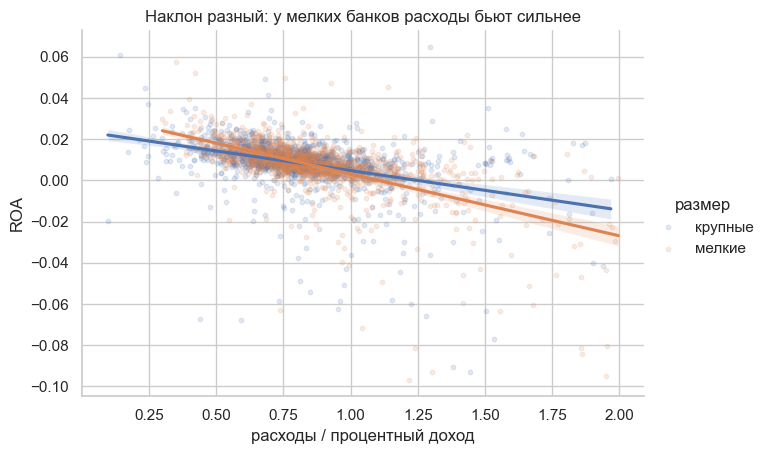

In [44]:
# Готовим выборку для картинки: 3000 строк с уже посчитанной колонкой big
show_big = banks.sample(3000, random_state=SEED).copy()

# Читаемые подписи вместо True/False
show_big["размер"] = show_big["big"].map({True: "крупные", False: "мелкие"})

# lmplot рисует отдельную линию регрессии для каждой группы (hue = "раскрасить по")
sns.lmplot(data=show_big, x="m_cost_income", y="e_roa", hue="размер",
           height=4.5, aspect=1.5,
           scatter_kws={"alpha": 0.15, "s": 10})
plt.title("Наклон разный: у мелких банков расходы бьют сильнее")
plt.xlabel("расходы / процентный доход")
plt.ylabel("ROA")
plt.show()

Линии не параллельны. Переведём картинку в модель.

In [45]:
model_inter_big = smf.ols("e_roa ~ m_cost_income * big", data=banks).fit()
print(model_inter_big.summary().tables[1])

                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0308      0.000    183.798      0.000       0.030       0.031
big[T.True]                  -0.0054      0.000    -23.693      0.000      -0.006      -0.005
m_cost_income                -0.0273      0.000   -145.681      0.000      -0.028      -0.027
m_cost_income:big[T.True]     0.0067      0.000     25.394      0.000       0.006       0.007


Четыре коэффициента, и каждый читается отдельно:

* `Intercept` = 0.0308 — свободный член у **мелких** банков (базовая группа);
* `big[T.True]` = −0.0054 — насколько ниже свободный член у крупных;
* `m_cost_income` = −0.0273 — наклон у **мелких**;
* `m_cost_income:big[T.True]` = +0.0067 — насколько наклон у крупных **отличается**.

То есть у крупных банков наклон равен −0.0273 + 0.0067 = −0.0206. Посчитаем обе прямые явно.

In [46]:
p = model_inter_big.params

# Собираем наклоны и свободные члены обеих групп
slope_small = p["m_cost_income"]
slope_large = p["m_cost_income"] + p["m_cost_income:big[T.True]"]

print("наклон у мелких банков:  ", round(slope_small, 5),
      f"->  +0.10 к cost/income = {slope_small * 0.10 * 10_000:+.0f} б.п. ROA")
print("наклон у крупных банков: ", round(slope_large, 5),
      f"->  +0.10 к cost/income = {slope_large * 0.10 * 10_000:+.0f} б.п. ROA")
print()
print("модель без взаимодействия обещала всем одинаковые",
      f"{model_big_ctrl.params['m_cost_income'] * 0.10 * 10_000:+.0f} б.п.")

наклон у мелких банков:   -0.02732 ->  +0.10 к cost/income = -27 б.п. ROA
наклон у крупных банков:  -0.02065 ->  +0.10 к cost/income = -21 б.п. ROA

модель без взаимодействия обещала всем одинаковые -24 б.п.


Разница в треть: те же 10 п.п. расходов стоят мелкому банку 27 б.п. прибыльности, а крупному — 21. Модель без взаимодействия давала всем одну цифру посередине, то есть систематически **недооценивала** уязвимость мелких банков и переоценивала уязвимость крупных.

### 9.3 Число × число

Когда оба признака непрерывны, устройство то же, но читать сложнее: групп нет, наклон меняется плавно.

Возьмём пару из первой лекции: списания и капитал.

In [47]:
# Звёздочка = a_nco_rate + c_equity_assets + их произведение
model_inter_num = smf.ols("e_roa ~ a_nco_rate * c_equity_assets", data=banks).fit()
print(model_inter_num.summary().tables[1])

model_add_num = smf.ols("e_roa ~ a_nco_rate + c_equity_assets", data=banks).fit()
print()
print("R^2 без взаимодействия:", round(model_add_num.rsquared, 4))
print("R^2 со взаимодействием:", round(model_inter_num.rsquared, 4))

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.0087      0.000     71.237      0.000       0.008       0.009
a_nco_rate                    -3.7733      0.025   -151.681      0.000      -3.822      -3.725
c_equity_assets                0.0125      0.001     11.196      0.000       0.010       0.015
a_nco_rate:c_equity_assets    20.5810      0.219     93.789      0.000      20.151      21.011

R^2 без взаимодействия: 0.2
R^2 со взаимодействием: 0.2674


**Сам коэффициент при произведении не интерпретируется.** Прочитать «+20.6» невозможно: у него единицы «ROA на квадрат доли». Интерпретируется **предельный эффект** — производная, которая теперь зависит от второго признака:

$$ \frac{\partial\, \text{ROA}}{\partial\, \text{списания}} = \beta_1 + \beta_3 \cdot \text{капитал} $$

Её и считают, подставляя реалистичные значения второго признака.

In [48]:
b1 = model_inter_num.params["a_nco_rate"]                       # наклон при нулевом капитале
b3 = model_inter_num.params["a_nco_rate:c_equity_assets"]       # добавка за единицу капитала

print("сколько ROA стоит рост списаний на 1 п.п.:")
for q in [0.1, 0.5, 0.9]:
    cap = banks["c_equity_assets"].quantile(q)      # значение капитала на перцентиле q
    effect = (b1 + b3 * cap) * 0.01 * 10_000        # предельный эффект в базисных пунктах
    print(f"  капитал/активы = {cap:.3f} (перцентиль {int(q * 100):2d}):  {effect:+6.0f} б.п.")

print(f"\nмодель без взаимодействия обещает всем одинаковые "
      f"{model_add_num.params['a_nco_rate'] * 0.01 * 10_000:+.0f} б.п.")

сколько ROA стоит рост списаний на 1 п.п.:
  капитал/активы = 0.073 (перцентиль 10):    -226 б.п.
  капитал/активы = 0.098 (перцентиль 50):    -177 б.п.
  капитал/активы = 0.143 (перцентиль 90):     -83 б.п.

модель без взаимодействия обещает всем одинаковые -168 б.п.


Разброс почти втрое: от −226 б.п. у слабо капитализированного банка до −83 б.п. у хорошо капитализированного.

### 9.4 Что мы измерили и чего не измерили

Мы измерили, что **наклон разный**. Мы не измерили, **почему** он разный.

У результата §9.2 есть как минимум два объяснения, и данные не позволяют выбрать между ними:

1. масштаб: у крупного банка структура доходов другая, и тот же процент расходов означает не то же самое;
2. отбор: мелкие банки с высокими расходами — это часто банки в беде, у которых проблемы идут пачкой.

Честная формулировка результата — «у мелких банков рост расходов **сопровождается** большим падением прибыльности». Формулировка «размер **защищает** от расходов» — уже причинное утверждение, и мы его не показали.

> Правило: взаимодействие — это утверждение о **форме связи**, а не о механизме. Оно говорит, что одна прямая на всех не годится. Почему не годится — вопрос к экономике, а не к регрессии.

## 10. Остатки: гетероскедастичность и корреляция

Коэффициенты мы прочитали. Теперь надо проверить, **можно ли верить стандартным ошибкам** — а значит и $t$, и $p$, и доверительным интервалам. Для этого смотрят не на модель, а на то, что она **не** объяснила: на остатки $e_i = y_i - \hat y_i$.

Идея простая. Если модель поймала всё, что можно, в остатках не должно остаться никакой структуры: ни тренда, ни воронки, ни зависимости от чего-либо. Всё, что в них видно, — это то, чего в модели не хватает.

### 10.1 Главная диагностическая картинка

Классика жанра — **остатки против предсказаний**. По горизонтали $\hat y$, по вертикали $e$.

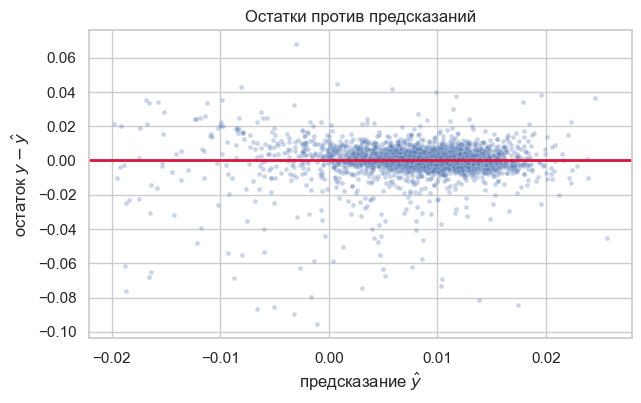

In [49]:
# Добавляем в таблицу колонки с предсказанием и остатком парной модели
banks["fitted"] = model_simple.fittedvalues
banks["resid"] = model_simple.resid

# Рисуем на случайной подвыборке, иначе 95 тысяч точек сольются
show_res = banks.sample(3000, random_state=SEED)

sns.scatterplot(data=show_res, x="fitted", y="resid", alpha=0.3, s=12)
plt.axhline(0, color="crimson", lw=2)   # горизонтальная линия на нуле
plt.title("Остатки против предсказаний")
plt.xlabel("предсказание $\\hat y$")
plt.ylabel("остаток $y - \\hat y$")
plt.show()

Что мы **хотели бы** увидеть: бесформенное облако постоянной толщины вокруг нуля.

Что видим: облако **сильно расширяется влево**. Там, где модель предсказывает низкий ROA, разброс остатков заметно больше. Это называется **гетероскедастичностью** — «разный разброс».

### 10.2 Гетероскедастичность в числах

Глаз обманывает: где точек больше, там кажется, что и разброс больше. Проверим счётом — разобьём наблюдения на 10 групп по признаку и посчитаем стандартное отклонение остатков внутри каждой.

(Предсказание здесь — убывающая функция расходов, поэтому «левый край» картинки выше — это правый край таблицы ниже. Информация та же, только зеркально.)

In [50]:
# pd.qcut делит на 10 равных по числу наблюдений групп (децили)
banks["x_bin"] = pd.qcut(banks["m_cost_income"], 10, labels=False)

# Внутри каждой группы: среднее значение признака, sd остатков, число строк
by_bin = banks.groupby("x_bin").agg(
    cost_income=("m_cost_income", "mean"),
    sd_остатка=("resid", "std"),
    строк=("resid", "size"))

by_bin.round(5)

,cost_income,sd_остатка,строк
x_bin,,,
0,0.46365,0.01018,9561
1,0.60592,0.00783,9561
2,0.67286,0.00723,9561
3,0.72729,0.00740,9561
4,0.77763,0.00743,9561
5,0.82817,0.00785,9561
6,0.88418,0.00799,9561
7,0.95465,0.00961,9561
8,1.06097,0.01174,9561


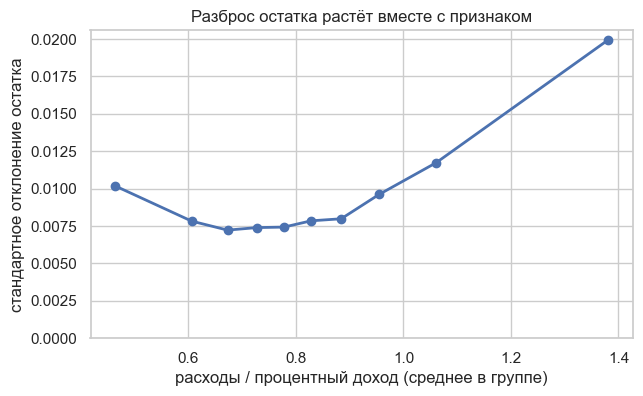

In [51]:
plt.plot(by_bin["cost_income"], by_bin["sd_остатка"], "o-", lw=2)
plt.title("Разброс остатка растёт вместе с признаком")
plt.xlabel("расходы / процентный доход (среднее в группе)")
plt.ylabel("стандартное отклонение остатка")
plt.ylim(0)
plt.show()

Разброс минимален в середине (0.0072) и растёт к обоим краям, особенно вправо — до 0.0200, почти втрое. Это уже не оптическая иллюзия.

Вроде все логично: банк с расходами 1.4 процентного дохода — это банк в беде, а банки в беде могут иметь любые показатели. Банк с расходами 0.7 — обычный работающий банк, и таких предсказать легче.

**Чем это опасно.** Сам коэффициент остаётся нормальным: гетероскедастичность его не смещает. Ломается другое — **формула стандартной ошибки**. Она выведена в предположении, что разброс ошибки одинаков во всех точках; когда это неверно, она даёт неправильное число. Именно это мы наблюдали в ранее: SE занижена почти вдвое, и 95 %-й доверительный интервал накрывает истину лишь в 75 % случаев.

**Как бороться, способ первый: робастные стандартные ошибки.** Формула, которая не предполагает одинакового разброса, а оценивает его в каждой точке отдельно. Поправка на степени свободы коротенькая

In [52]:
# Одна и та же модель, две формулы стандартных ошибок
m_naive = smf.ols("e_roa ~ m_cost_income + a_npl_gross_loans + c_equity_assets + e_nim",
                  data=banks).fit()
m_robust = smf.ols("e_roa ~ m_cost_income + a_npl_gross_loans + c_equity_assets + e_nim",
                   data=banks).fit(cov_type="HC1")

# Собираем в одну таблицу для сравнения
se_compare = pd.DataFrame({
    "коэффициент": m_naive.params,
    "SE обычная": m_naive.bse,
    "SE робастная": m_robust.bse,
    "t обычная": m_naive.tvalues,
    "t робастная": m_robust.tvalues,
})
se_compare.round(4)

,коэффициент,SE обычная,SE робастная,t обычная,t робастная
Intercept,0.0168,0.0002,0.0009,90.3055,18.2718
m_cost_income,-0.0183,0.0001,0.0003,-140.2197,-53.3599
a_npl_gross_loans,-0.1157,0.0012,0.0074,-97.0153,-15.6074
c_equity_assets,0.0204,0.0010,0.0015,20.6720,13.5290
e_nim,0.1720,0.0024,0.0217,70.8756,7.9349


Коэффициенты не изменились — как и обещано. А $t$-статистики упали, и заметно: у расходов со 140 до 53, у просрочки с 97 до 16, у маржи с 71 до 8. Это в два-девять раз, в зависимости от признака. Все они остаются значимыми, но степень уверенности была преувеличена.

> Совет: робастные SE почти ничего не стоят и почти никогда не вредят (почти). Ставить их по умолчанию — хороший тон.

**Как бороться, способ второй: преобразование данных.** Иногда гетероскедастичность возникает не из-за чего-то глубокого, а просто потому, что величина измерена в неудачной шкале. Классический пример — деньги в уровнях.

In [53]:
# Берём банки с положительной прибылью: логарифм отрицательного числа не существует
money = banks[banks["net_income"] > 0].copy()

# Модель в уровнях: прибыль в тысячах долларов против активов в тысячах долларов
model_levels = smf.ols("net_income ~ assets", data=money).fit()
money["resid_levels"] = model_levels.resid

# Модель в логарифмах: np.log прямо в формуле, statsmodels это умеет
model_logs = smf.ols("np.log(net_income) ~ np.log(assets)", data=money).fit()
money["resid_logs"] = model_logs.resid

print("R^2 в уровнях:    ", round(model_levels.rsquared, 4))
print("R^2 в логарифмах: ", round(model_logs.rsquared, 4))

R^2 в уровнях:     0.8315
R^2 в логарифмах:  0.7701


In [54]:
# Считаем sd остатков по децилям активов для обеих моделей
money["a_bin"] = pd.qcut(money["assets"], 10, labels=False)

by_size = money.groupby("a_bin").agg(
    активы=("assets", "median"),
    sd_в_уровнях=("resid_levels", "std"),
    sd_в_логарифмах=("resid_logs", "std"))

by_size.round(3)

,активы,sd_в_уровнях,sd_в_логарифмах
a_bin,,,
0,60233.0,107.121,0.848
1,83300.0,138.224,0.847
2,110189.5,186.032,0.805
3,143501.0,241.884,0.776
4,188489.5,304.844,0.796
5,252649.5,406.805,0.745
6,348021.0,548.422,0.725
7,516513.5,841.749,0.699
8,919408.5,1763.358,0.695


В уровнях разброс остатка растёт с 107 до 109 530 — в тысячу раз. Никакие робастные ошибки такую конструкцию не спасут: модель просто неправильно поставлена. Крупный банк и зарабатывает больше, и ошибается в абсолютных долларах больше — это арифметика, а не эконометрика.

В логарифмах разброс идёт от 0.85 до 0.66 — практически ровно. Модель стала мультипликативной: она объясняет не «сколько долларов прибыли», а «на сколько процентов больше».

> И сразу ловушка: $R^2$ упал с 0.83 до 0.77, а модель стала лучше. Противоречия нет — **это $R^2$ для разных откликов**. В первом случае объясняется разброс `net_income`, во втором — разброс `log(net_income)`. Это разные величины с разным TSS, и сравнивать доли объяснённого между ними бессмысленно. $R^2$ сравним только внутри одной и той же зависимой переменной на одной и той же выборке.

Заодно посмотрите на коэффициент логарифмической модели — у него отдельная, очень удобная интерпретация.

In [55]:
print(model_logs.summary().tables[1])
print()
print("коэффициент при log(assets) =", round(model_logs.params["np.log(assets)"], 3))

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -6.7560      0.025   -272.918      0.000      -6.805      -6.707
np.log(assets)     1.0487      0.002    534.938      0.000       1.045       1.053

коэффициент при log(assets) = 1.049


**В модели «лог на лог» коэффициент — это эластичность.** Читается: активы больше на 1 % → прибыль больше на 1.05 %. Никаких переводов в базисные пункты не нужно, число уже в человеческих единицах.

Шпаргалка по логарифмам:

| Модель | Коэффициент читается как |
|---|---|
| $y = \beta_0 + \beta_1 x$ | $+1$ единица $x$ → $+\beta_1$ единиц $y$ |
| $\log y = \beta_0 + \beta_1 x$ | $+1$ единица $x$ → $+100 \cdot \beta_1$ **процентов** $y$ |
| $y = \beta_0 + \beta_1 \log x$ | $+1$ % $x$ → $+\beta_1 / 100$ единиц $y$ |
| $\log y = \beta_0 + \beta_1 \log x$ | $+1$ % $x$ → $+\beta_1$ **процентов** $y$ (эластичность) |

### 10.3 Корреляция остатков

Второе предположение, стоящее за формулой SE: **наблюдения независимы**. У нас панель — один банк встречается в таблице по сто раз подряд. Независимости там взяться неоткуда.

Посмотрим на остатки одного банка во времени.

банк: Arrow Bank National Association | кварталов: 101


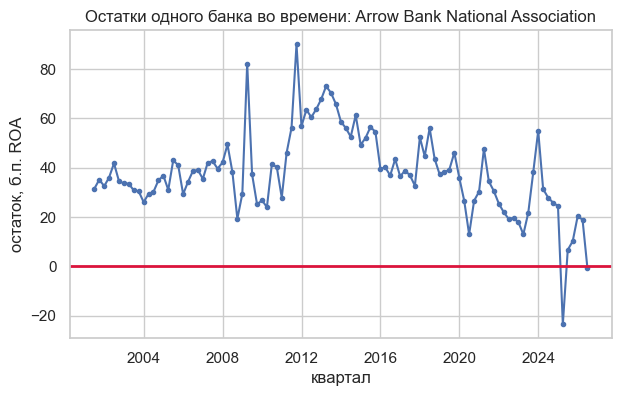

In [56]:
# Берём банк с самой длинной историей наблюдений
one_cert = banks["cert"].value_counts().index[0]
one_bank = banks[banks["cert"] == one_cert]

print("банк:", one_bank["name"].iloc[0], "| кварталов:", len(one_bank))

plt.plot(one_bank["repdte"], one_bank["resid"] * 10_000, "o-", ms=3)
plt.axhline(0, color="crimson", lw=2)
plt.title(f"Остатки одного банка во времени: {one_bank['name'].iloc[0]}")
plt.xlabel("квартал")
plt.ylabel("остаток, б.п. ROA")
plt.show()

Это не шум. Остатки идут длинными сериями по одну сторону от нуля: банк, который модель недооценила в этом квартале, будет недооценён и в следующем, и через год. У банка есть постоянные особенности — регион, менеджмент, ниша, — которых в модели нет, и они сидят в остатке годами.

Измерим это числом: посчитаем корреляцию остатка с самим собой, сдвинутым на несколько кварталов назад.

In [57]:
rows = []
for lag in [1, 2, 4, 8, 12]:
    # .groupby("cert")["resid"].shift(lag) — сдвиг ВНУТРИ каждого банка,
    # чтобы не сравнивать конец истории одного банка с началом истории другого
    shifted = banks.groupby("cert")["resid"].shift(lag)
    rows.append({"сдвиг, кварталов": lag,
                 "корреляция остатков": banks["resid"].corr(shifted)})

pd.DataFrame(rows).set_index("сдвиг, кварталов").round(3)

,корреляция остатков
"сдвиг, кварталов",
1,0.486
2,0.458
4,0.414
8,0.287
12,0.217


Корреляция 0.49 через квартал и всё ещё 0.22 через три года. Она затухает очень медленно — а это подпись **постоянного банковского эффекта**, а не уходящего шока.

**Чем это опасно.** Тем же, чем гетероскедастичность, только сильнее. Формула SE считает, что у нас 95 610 независимых наблюдений. На деле у нас 2 267 банков, каждый из которых рассказывает почти одно и то же по сорок раз. Реальной информации в выборке в разы меньше, чем строк, — и SE занижена соответственно.

**Как бороться: кластерные стандартные ошибки.** Это та же идея, что робастные, но группировка задаётся явно: «внутри банка допускаем любую зависимость, между банками — считаем независимыми».

In [58]:
# cov_type="cluster", groups — колонка, задающая группы. Здесь группа = банк.
m_cluster = smf.ols("e_roa ~ m_cost_income + a_npl_gross_loans + c_equity_assets + e_nim",
                    data=banks).fit(cov_type="cluster",
                                    cov_kwds={"groups": banks["cert"]})

se_all = pd.DataFrame({
    "коэффициент": m_naive.params,
    "SE обычная": m_naive.bse,
    "SE робастная": m_robust.bse,
    "SE кластерная": m_cluster.bse,
    "t обычная": m_naive.tvalues,
    "t кластерная": m_cluster.tvalues,
})
se_all.round(4)

,коэффициент,SE обычная,SE робастная,SE кластерная,t обычная,t кластерная
Intercept,0.0168,0.0002,0.0009,0.0020,90.3055,8.5409
m_cost_income,-0.0183,0.0001,0.0003,0.0009,-140.2197,-20.3029
a_npl_gross_loans,-0.1157,0.0012,0.0074,0.0233,-97.0153,-4.9727
c_equity_assets,0.0204,0.0010,0.0015,0.0038,20.6720,5.4135
e_nim,0.1720,0.0024,0.0217,0.0458,70.8756,3.7524


Кластерные ошибки в разы больше робастных: у просрочки $t$ падает с 97 до 5, у капитала с 21 до 5. Все признаки остаются значимыми — но «значимый на уровне $10^{-200}$» и «значимый на уровне $10^{-6}$» это очень разные степени уверенности.

> **Что чем лечится.** Гетероскедастичность → робастные SE (`HC1`). Зависимость внутри группы → кластерные SE (`cluster`). Неправильная шкала → преобразование ($\log$). И ни одна из этих поправок **не чинит улучшает ваши данные**: если в модели не хватает важного признака, честный доверительный интервал будет построен вокруг неправильного числа.

### 10.4 Структура в остатках: добавляем признак

Последний способ борьбы — самый содержательный. Если остаток систематически связан с чем-то, чего в модели нет, надо это что-то в модель добавить.

Проверяем: связан ли остаток парной модели с просрочкой?

In [59]:
# Средний остаток внутри децилей по просрочке.
# Если модель ничего не упустила, все средние должны быть около нуля.
banks["npl_bin"] = pd.qcut(banks["a_npl_gross_loans"], 10, labels=False, duplicates="drop")

by_npl = banks.groupby("npl_bin").agg(
    просрочка=("a_npl_gross_loans", "mean"),
    средний_остаток_бп=("resid", lambda s: s.mean() * 10_000))

by_npl.round(4)

,просрочка,средний_остаток_бп
npl_bin,,
0,0.0000,1.8681
1,0.0009,16.0672
2,0.0023,17.5713
3,0.0041,18.5791
4,0.0062,17.8301
5,0.0089,16.9318
6,0.0126,13.3808
7,0.0182,5.4199
8,0.0289,-13.4843


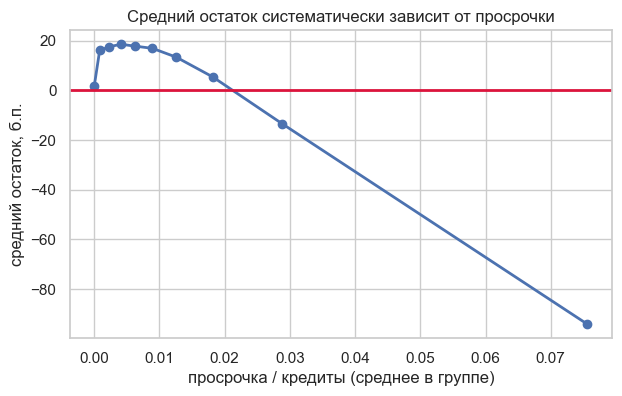

In [60]:
plt.plot(by_npl["просрочка"], by_npl["средний_остаток_бп"], "o-", lw=2)
plt.axhline(0, color="crimson", lw=2)
plt.title("Средний остаток систематически зависит от просрочки")
plt.xlabel("просрочка / кредиты (среднее в группе)")
plt.ylabel("средний остаток, б.п.")
plt.show()

Вот она, структура: в группе с самой высокой просрочкой модель систематически **завышает** ROA на 94 б.п. Это не случайность и не гетероскедастичность — это пропущенный признак.

Лечится добавлением просрочки в модель. После этого средний остаток по тем же группам обязан выровняться — по построению МНК остаток ортогонален каждому включённому признаку.

In [61]:
# Модель с просрочкой — считаем её остаток и повторяем ту же проверку
banks["resid2"] = smf.ols("e_roa ~ m_cost_income + a_npl_gross_loans",
                          data=banks).fit().resid

check = banks.groupby("npl_bin").agg(
    просрочка=("a_npl_gross_loans", "mean"),
    остаток_старый_бп=("resid", lambda s: s.mean() * 10_000),
    остаток_новый_бп=("resid2", lambda s: s.mean() * 10_000))

check.round(3)

,просрочка,остаток_старый_бп,остаток_новый_бп
npl_bin,,,
0,0.000,1.868,-15.501
1,0.001,16.067,0.481
2,0.002,17.571,3.123
3,0.004,18.579,6.188
4,0.006,17.830,7.796
5,0.009,16.932,9.596
6,0.013,13.381,10.134
7,0.018,5.420,8.179
8,0.029,-13.484,0.918


Структура ослабла втрое: размах средних остатков был от +19 до −94 б.п., стал от +10 до −31.

Но она **не исчезла**. В последнем дециле модель всё ещё завышает ROA на 31 б.п. Это остаток другой природы: связь ROA с просрочкой не совсем прямая, у сильно проблемных банков она круче, чем обещает прямая. Ровно эту картинку мы видели в §4 первой лекции, когда KNN уходил ниже линии регрессии на высокой просрочке. Лечится это уже не новым признаком, а нелинейной спецификацией — логарифмом, квадратом или взаимодействием.

> Осторожно с обобщением. «Добавить признак» лечит только тот случай, когда признак у вас **есть**. Пропущенная переменная, которую никто не измерял, останется в остатке и утащит с собой часть коэффициентов — и никакая диагностика её не покажет.

## 11. Коллинеарность и выбросы

### 11.1 Коллинеарность

**Коллинеарность** — это когда два (или несколько) признаков несут почти одну и ту же информацию.

В наших данных есть готовая пара близнецов: `c_equity_assets` (капитал / активы) и `c_tier1_leverage` (капитал первого уровня / активы). Это два способа померить одно и то же.

корреляция двух мер капитала: 0.886


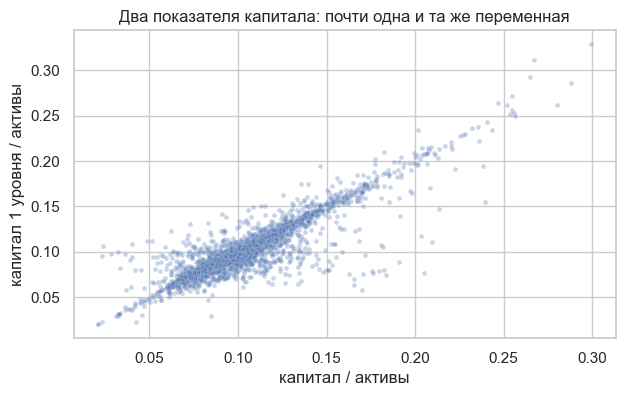

In [62]:
print("корреляция двух мер капитала:",
      round(banks["c_equity_assets"].corr(banks["c_tier1_leverage"]), 3))

sns.scatterplot(data=show, x="c_equity_assets", y="c_tier1_leverage", alpha=0.3, s=12)
plt.title("Два показателя капитала: почти одна и та же переменная")
plt.xlabel("капитал / активы")
plt.ylabel("капитал 1 уровня / активы")
plt.show()

Посмотрим, что происходит, когда обоих сажают в одну модель.

In [63]:
base_formula = "e_roa ~ m_cost_income + a_npl_gross_loans + e_nim"

# Модель с одной мерой капитала и модель с обеими
m_one = smf.ols(base_formula + " + c_equity_assets", data=banks).fit()
m_two = smf.ols(base_formula + " + c_equity_assets + c_tier1_leverage", data=banks).fit()

collin = pd.DataFrame({
    "коэффициент (один)": m_one.params,
    "SE (один)": m_one.bse,
    "коэффициент (оба)": m_two.params,
    "SE (оба)": m_two.bse,
}).loc[["c_equity_assets", "c_tier1_leverage", "m_cost_income"]]

print(collin.round(4))
print()
print("R^2 с одной мерой капитала:", round(m_one.rsquared, 5))
print("R^2 с обеими:              ", round(m_two.rsquared, 5))

                  коэффициент (один)  SE (один)  коэффициент (оба)  SE (оба)
c_equity_assets               0.0204     0.0010             0.0134    0.0021
c_tier1_leverage                 NaN        NaN             0.0083    0.0022
m_cost_income                -0.0183     0.0001            -0.0182    0.0001

R^2 с одной мерой капитала: 0.36102
R^2 с обеими:               0.36112


Читаем внимательно:

* Коэффициент при капитале **упал на треть**: с 0.0204 до 0.0134, а второй близнец забрал себе 0.0083. МНК не может решить, кому из них приписать общий эффект, и делит его между ними более или менее случайно.
* Стандартная ошибка **выросла вдвое**: с 0.0010 до 0.0021. (Прочерк в первой колонке у `c_tier1_leverage` — потому что в первой модели этого признака просто нет.)
* $R^2$ при этом **не изменился в пятом знаке**: 0.36101 против 0.36112.

Последняя строчка — главная. **Коллинеарность не портит прогноз. Она разрушает интерпретацию.** Модель предсказывает ровно так же хорошо; просто больше нельзя сказать, какая из двух мер капитала «работает».

**Как её измерить.** Стандартный инструмент — **VIF** (variance inflation factor, фактор инфляции дисперсии):

$$ \text{VIF}_j = \frac{1}{1 - R^2_j}, \qquad R^2_j = R^2 \text{ регрессии } x_j \text{ на все остальные признаки} $$

Смысл прямой: $R^2_j$ — это доля признака $x_j$, которую можно предсказать по остальным. Если её много, «своей» вариации у признака почти не остаётся, и оценивать его коэффициент не на чем. Дисперсия оценки растёт ровно в VIF раз, а доверительный интервал — в $\sqrt{\text{VIF}}$ раз.

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = ["c_equity_assets", "c_tier1_leverage",
                "m_cost_income", "a_npl_gross_loans", "e_nim"]

# Функции нужна матрица признаков с колонкой единиц (свободный член)
X_vif = np.column_stack([np.ones(len(banks))] + [banks[f].to_numpy() for f in vif_features])

rows = []
for i, f in enumerate(vif_features):
    v = variance_inflation_factor(X_vif, i + 1)   # +1: нулевая колонка — единицы
    rows.append({"признак": f,
                 "VIF": v,
                 "R^2_j": 1 - 1 / v,
                 "во сколько раз шире ДИ": np.sqrt(v)})

pd.DataFrame(rows).set_index("признак").round(2)

,VIF,R^2_j,во сколько раз шире ДИ
признак,,,
c_equity_assets,4.65,0.78,2.16
c_tier1_leverage,4.69,0.79,2.17
m_cost_income,1.15,0.13,1.07
a_npl_gross_loans,1.10,0.09,1.05
e_nim,1.05,0.05,1.03


У двух мер капитала VIF около 4.7: 79 % каждой из них объясняется остальными признаками, и доверительный интервал в 2.2 раза шире, чем был бы без близнеца. У остальных признаков VIF около единицы — они несут свою информацию.

Порог тревоги обычно называют $\text{VIF} > 5$ или $> 10$, но это соглашение, а не закон. Важно не число, а стал ли интервал слишком широким **для вашего вопроса**.

Что делать, по убыванию предпочтительности:

1. **Выбросить дубликат.** Если два признака измеряют одно и то же, вопрос «который важнее» бессмыслен по построению. Это наш случай.
2. **Сложить их в один индекс** (среднее, главная компонента). Вы отказываетесь разделять эффект — но говорите об этом вслух.
3. **Оставить обоих и отчитаться о совместном $F$-тесте.** Каждый $t$ по отдельности бессилен, а $F$ на пару остаётся мощным. Часто это и есть честный ответ.
4. **Ничего не делать**, если вам нужен только прогноз: на него коллинеарность не влияет.

### 11.2 Выбросы

Выброс — наблюдение, стоящее далеко от остальных. Для регрессии важно различать два вида:

* **выброс по $Y$** — точка с огромным остатком. Портит оценку разброса ошибки, а значит SE и $R^2$;
* **выброс по $X$** (говорят: точка с большим **плечом**, leverage) — точка, у которой признак далеко от всех остальных. Такая точка может утащить за собой всю прямую.

Вторая опаснее. Посмотрим на реальный пример в наших данных: отношение кредитов к депозитам.

In [65]:
print(banks["l_loans_deposits"].describe(percentiles=[0.5, 0.99, 0.999]).round(3))
print()
print("строк со значением больше 2:", (banks["l_loans_deposits"] > 2).sum(),
      f"({(banks['l_loans_deposits'] > 2).mean():.2%} выборки)")

count    95610.000
mean        14.223
std        707.324
min          0.000
50%          0.820
99%          1.390
99.9%       41.457
max      68418.953
Name: l_loans_deposits, dtype: float64

строк со значением больше 2: 315 (0.33% выборки)


Медиана 0.82, 99-й перцентиль 1.39 — и максимум 68 419. Это банки с почти нулевыми депозитами: деление на «почти ноль» даёт «почти бесконечность». Ровно тот сюжет, что был в §2.2 первой лекции с `m_cost_income`.

315 строк — это треть процента выборки. Посмотрим, что они делают с регрессией.

In [66]:
# Модель на всех строках и на строках без выбросов
out_all = smf.ols("e_roa ~ l_loans_deposits", data=banks).fit()
trimmed = banks[banks["l_loans_deposits"].between(0, 2)]
out_trim = smf.ols("e_roa ~ l_loans_deposits", data=trimmed).fit()

# Печатаем f-строками: коэффициенты отличаются на порядки, в таблице они
# отобразились бы в неудобной научной нотации.
for name, m in [("все 95 610 строк", out_all), ("без 315 выбросов", out_trim)]:
    print(f"{name}:")
    print(f"   коэффициент  = {m.params['l_loans_deposits']:+.2e}")
    print(f"   t-статистика = {m.tvalues['l_loans_deposits']:+.2f}")
    print(f"   R^2          = {m.rsquared:.5f}")

все 95 610 строк:
   коэффициент  = +1.08e-07
   t-статистика = +1.96
   R^2          = 0.00004
без 315 выбросов:
   коэффициент  = -1.72e-03
   t-статистика = -9.40
   R^2          = 0.00093


**Знак коэффициента перевернулся.** На всех данных связь положительная ($t = +2.0$), без трёх сотен строк — отрицательная и уверенная ($t = -9.4$). Треть процента наблюдений определяет вывод.

Почему так: точка с $x = 68\,419$ находится в шестидесяти тысячах единиц от остальных. В сумме квадратов её остаток умножается на гигантское плечо, и МНК разворачивает прямую, лишь бы к ней приблизиться.

Посмотрим на механизм в чистом виде. Возьмём 40 нормальных банков и добавим к ним **одну** выдуманную точку с экстремальным $x$ — в двух вариантах, отличающихся только высотой.

In [67]:
# 40 обычных наблюдений
demo = banks.sample(40, random_state=SEED)[["m_cost_income", "e_roa"]].copy()
fit_clean = smf.ols("e_roa ~ m_cost_income", data=demo).fit()

# Вариант A: точка далеко справа и НЕ на продолжении тренда
extra_a = pd.DataFrame({"m_cost_income": [6.0], "e_roa": [0.010]})
fit_a = smf.ols("e_roa ~ m_cost_income",
                data=pd.concat([demo, extra_a], ignore_index=True)).fit()

# Вариант B: точка далеко справа и ровно на продолжении тренда
extra_b = pd.DataFrame({"m_cost_income": [6.0], "e_roa": [-0.20]})
fit_b = smf.ols("e_roa ~ m_cost_income",
                data=pd.concat([demo, extra_b], ignore_index=True)).fit()

for name, f in [("без выброса      ", fit_clean),
                ("A: не по тренду  ", fit_a),
                ("B: точно по тренду", fit_b)]:
    print(f"{name}: наклон = {f.params['m_cost_income']:+.4f}   R^2 = {f.rsquared:.3f}")

без выброса      : наклон = -0.0406   R^2 = 0.507
A: не по тренду  : наклон = -0.0041   R^2 = 0.049
B: точно по тренду: наклон = -0.0402   R^2 = 0.903


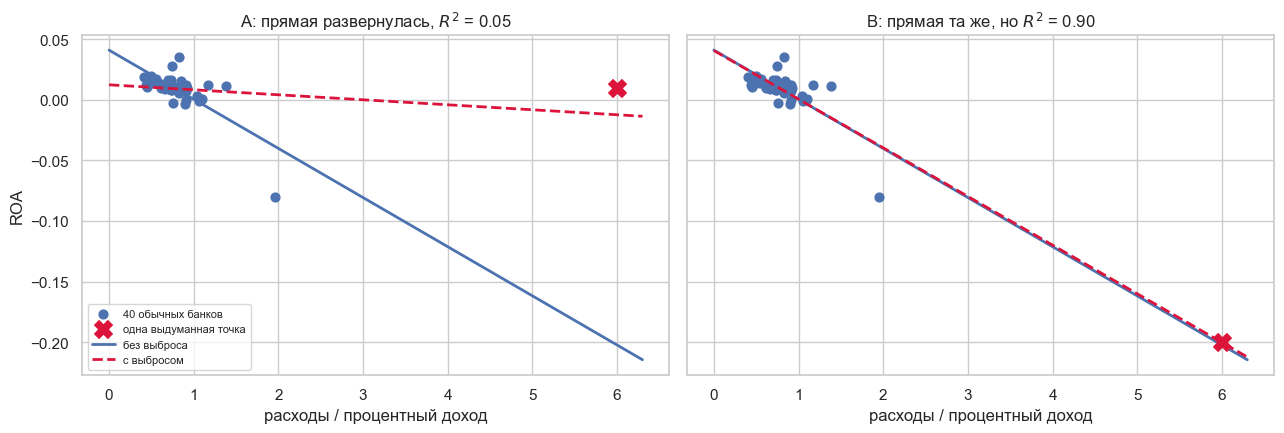

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
gx = np.linspace(0, 6.3, 50)   # сетка, на которой рисуем прямые

# Своя маленькая функция: рисует одну панель. Пишем один раз, вызываем дважды.
def outlier_panel(ax, extra, fit_dirty, title):
    ax.scatter(demo["m_cost_income"], demo["e_roa"], s=40, label="40 обычных банков")
    ax.scatter(extra["m_cost_income"], extra["e_roa"], s=160, color="crimson",
               marker="X", zorder=5, label="одна выдуманная точка")
    ax.plot(gx, fit_clean.params["Intercept"] + fit_clean.params["m_cost_income"] * gx,
            lw=2, label="без выброса")
    ax.plot(gx, fit_dirty.params["Intercept"] + fit_dirty.params["m_cost_income"] * gx,
            lw=2, ls="--", color="crimson", label="с выбросом")
    ax.set_title(title)
    ax.set_xlabel("расходы / процентный доход")

outlier_panel(axes[0], extra_a, fit_a,
              f"A: прямая развернулась, $R^2$ = {fit_a.rsquared:.2f}")
outlier_panel(axes[1], extra_b, fit_b,
              f"B: прямая та же, но $R^2$ = {fit_b.rsquared:.2f}")

axes[0].set_ylabel("ROA")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Одна точка из сорока одной — и два противоположных способа всё испортить.

**Вариант A.** Точка стоит далеко справа и не там, где ожидает прямая. Наклон падает с −0.041 до −0.004 — в десять раз, — а $R^2$ рушится с 0.51 до 0.05. Модель развернуло одно наблюдение.

**Вариант B — коварнее.** Точка лежит ровно на продолжении тренда. Наклон почти не изменился, зато $R^2$ **вырос с 0.51 до 0.90**. Никакой новой информации не появилось: мы добавили одну строку, которая просто очень далеко. Она раздула TSS — общий разброс $Y$ вокруг среднего, — и доля «объяснённого» механически подскочила.

Мораль варианта B стоит запомнить отдельно: **$R^2$ можно поднять почти до единицы, ничего не улучшив, — достаточно, чтобы в выборке нашлась пара очень далёких точек.** Высокий $R^2$ на данных с длинными хвостами почти ничего не значит.

Отсюда практика:

1. **Смотрите на `.describe()` и гистограммы до того, как оценивать модель** — ровно как в §2 первой лекции. Большинство выбросов видно сразу.
2. **Решение о фильтре принимайте явно и комментируйте его.** «Убрал хвост» — не объяснение; «отбросил банки с депозитами меньше 1 % активов, потому что отношение к депозитам для них не определено» — объяснение.
3. **Проверяйте устойчивость.** Посчитайте модель с выбросами и без. Если выводы разные — это и есть главный результат, и о нём надо сказать.
4. **Не удаляйте наблюдения только за то, что у них большой остаток.** Точка с большим остатком часто и есть самое интересное в данных: банк перед крахом выглядит как выброс именно потому, что он банк перед крахом.

## Итого

1. **Линейная регрессия** — это решение приблизить связь прямой: $Y = \beta_0 + \beta_1 X + \varepsilon$. Не каузальность, а ассоциация.
2. **МНК** выбирает коэффициенты, минимизирующие RSS — сумму квадратов вертикальных отклонений. Поверхность RSS — чаша с единственным дном (в отличие от моделей, которые будем рассматривать позже).
3. **Коэффициент — случайная величина.** Стандартная ошибка это разброс её распределения, доверительный интервал — тот же разброс в удобной форме. «95 %» — про долю накрывающих интервалов при повторении исследования, а не про вероятность для истины.
4. **$t$, $F$, $p$ измеряют точность измерения, а не силу эффекта.** При большом $n$ значимо всё. О важности судят по величине коэффициента в понятных единицах.
5. **$R^2$ — доля объяснённого разброса.** В парной регрессии это $r^2$; в множественной — квадрат корреляции факта с предсказанием. Он всегда растёт при добавлении признаков, поэтому для выбора модели не годится. Степени свободы $n - p - 1$ — это то, что осталось от выборки после подгонки.
6. **«При прочих равных»** — не странность, а перераспределение дисперсии между коррелированными признаками.
7. **Категории кодируются фиктивными переменными**, на одну меньше числа категорий; коэффициент читается как отклонение от базовой. Нужность всей группы проверяется $F$-тестом.
8. **Взаимодействие** снимает постулат «эффект одинаков для всех». Читается не по коэффициенту при произведении, а по предельному эффекту при разных значениях второго признака.
9. **Гетероскедастичность и корреляция остатков** ломают не коэффициент, а стандартную ошибку. Лечатся робастными и кластерными SE, а иногда преобразованием шкалы или добавлением признака.
10. **Коллинеарность** не портит прогноз, но разрушает интерпретацию. **Выбросы по $X$** могут перевернуть знак коэффициента и при этом улучшить $R^2$.

И сквозная мысль всей лекции: **регрессия оценивает ассоциации.** «Наклон разный» и «одно влияет на другое» — по-прежнему разные утверждения.

---

# Домашнее задание

Пройти те же шаги с **другим откликом**. Возьмите `e_nim` (процентная маржа) вместо `e_roa` — ту же переменную, что была откликом в домашнем задании первой лекции.

Копировать код из лекции можно и нужно — менять придётся немногое. Смысл задания не в том, чтобы написать новый код, а в том, чтобы **выбрать** признаки, спецификацию и поправки — и уметь объяснить каждый выбор.

### 1. Данные и парная регрессия

`TODO(hw2-a)`. Загрузите панель, примените свой фильтр (можно взять из первой домашки) и сохраните результат в `hw`. Выберите **один** признак, который по вашей гипотезе объясняет `e_nim`, постройте диаграмму рассеяния и оцените парную регрессию. Напечатайте полный `summary()`.

Ниже словами: прочитайте коэффициент наклона **в понятных единицах** (на реалистичный шаг признака, в базисных пунктах маржи) и объясните, почему свободный член здесь интерпретировать не стоит.

In [69]:
# TODO(hw2-a): фильтр -> hw, диаграмма рассеяния, парная регрессия, summary().

> _Ваш ответ (2–3 предложения):_

### 2. Стандартные ошибки и доверительные интервалы

`TODO(hw2-b)`. Повторите эксперимент из §4 на своей модели: 300 раз возьмите случайные 500 строк, оцените регрессию и сложите оценки наклона в список. Постройте гистограмму. Сравните три числа: разброс из эксперимента, обычную SE и робастную SE (`cov_type="HC1"`) на одной выборке из 500 строк.

Ниже словами: какая формула ближе к эксперименту и почему.

In [70]:
# TODO(hw2-b): 300 повторов по 500 строк, гистограмма оценок,
# сравнение sd эксперимента с обычной и робастной SE.

> _Ваш ответ (2–3 предложения):_

### 3. Множественная регрессия

`TODO(hw2-c)`. Добавьте ещё **два-три** признака. Оцените модель, напечатайте таблицу коэффициентов, $R^2$ и скорректированный $R^2$. Постройте табличку, где каждый коэффициент переведён в эффект от изменения признака на одно стандартное отклонение, вместе с границами доверительного интервала.

Ниже ~100 слов: как изменился коэффициент при вашем первом признаке по сравнению с парной регрессией и что это означает содержательно.

In [71]:
# TODO(hw2-c): множественная регрессия, R^2 и adj R^2,
# таблица эффектов "+1 sd" с доверительными интервалами.

> _Ваш ответ (~100 слов):_

### 4. Категориальная переменная

`TODO(hw2-d)`. Добавьте в модель категориальный признак: `charter_class` (не забудьте отбросить редкие категории) либо свой собственный — например, десятилетие (`hw["repdte"].dt.year // 10`) или регион. Напечатайте коэффициенты и объясните, относительно какой базовой категории они читаются. Проверьте $F$-тестом, нужна ли группа целиком, и сравните $R^2$ с моделью без неё.

Ниже словами: значим ли признак и **важен** ли он — это два разных ответа.

In [72]:
# TODO(hw2-d): категориальный признак через C(...), F-тест на всю группу,
# сравнение R^2 с моделью без него.

> _Ваш ответ (2–3 предложения):_

### 5. Взаимодействие

`TODO(hw2-e)`. Добавьте одно взаимодействие: либо категория × число (как в §9.2), либо число × число (как в §9.3). Постройте картинку, которая его показывает, и посчитайте **предельный эффект** первого признака при трёх разных значениях второго (перцентили 10 / 50 / 90 — или по категориям, если вторая переменная категориальная).

Ниже ~120 слов: что показывает взаимодействие и — отдельным предложением — какое утверждение вы по этим оценкам сделать **не** имеете права.

In [73]:
# TODO(hw2-e): модель со взаимодействием, картинка,
# предельный эффект при трёх значениях второго признака.

> _Ваш ответ (~120 слов):_

### 6. Диагностика

`TODO(hw2-f)`. Проверьте свою итоговую модель по четырём пунктам из §10–§11:

1. график «остатки против предсказаний» и таблица sd остатка по децилям — есть ли гетероскедастичность;
2. корреляция остатков внутри банка при сдвигах 1, 4, 8 кварталов;
3. сравнение обычных, робастных и кластерных стандартных ошибок в одной таблице;
4. VIF ваших признаков.

Ниже ~120 слов: какие стандартные ошибки вы выбираете для итогового отчёта и почему; изменились ли ваши выводы из задания 3 после этого выбора.

In [74]:
# TODO(hw2-f): остатки против предсказаний, sd по децилям, автокорреляция,
# таблица SE (обычные / робастные / кластерные), VIF.

> _Ваш ответ (~120 слов):_